In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
import gc
import warnings
import time
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau # Thêm thư viện ở đây
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

print("="*60)
print("🚀 KHỞI ĐỘNG PIPELINE: TRANSFORMER BASELINE (CHƯA CÂN BẰNG)")
print("="*60)

# ==============================================================================
# 1️⃣ ĐỌC DỮ LIỆU & CHIA TẬP USER
# ==============================================================================
print("\n[1/4] Đang đọc file Parquet và phân bổ User...")
file_path = '/kaggle/input/datasets/phanthanhhoang/cert-r42-session/session_r4.2.parquet'
df = pd.read_parquet(file_path)
df['insider'] = df['insider'].astype(int)

df = df.sort_values(by=['user', 'starttime']).reset_index(drop=True)

exclude_cols = ['insider', 'starttime', 'endtime', 'sessionid', 'user', 'pc', 'day', 'week']
feature_cols = [col for col in df.columns if col not in exclude_cols]

user_agg = df.groupby('user', as_index=False)['insider'].max()
unique_users = user_agg['user'].values
user_labels = user_agg['insider'].values

sgkf_test = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
train_val_idx, test_user_idx = next(sgkf_test.split(unique_users, user_labels, unique_users))

train_val_users = unique_users[train_val_idx]
train_val_labels = user_labels[train_val_idx]
test_users = unique_users[test_user_idx]

try:
    skf_val = StratifiedKFold(n_splits=8, shuffle=True, random_state=42)
    train_idx, val_idx = next(skf_val.split(train_val_users, train_val_labels))
    train_users = train_val_users[train_idx]
    val_users = train_val_users[val_idx]
except ValueError:
    print("   [!] Kịch bản hiếm quá không Stratify Val được, chuyển sang cắt ngẫu nhiên Val...")
    train_users, val_users = train_test_split(train_val_users, test_size=0.125, random_state=42, stratify=train_val_labels)

df_train = df[df['user'].isin(train_users)].copy()
df_val   = df[df['user'].isin(val_users)].copy()
df_test  = df[df['user'].isin(test_users)].copy()

del df, user_agg
gc.collect()

# ==============================================================================
# 2️⃣ TẠO KHỐI 3D BẰNG SLIDING WINDOW
# ==============================================================================
print("\n[2/4] Đang cuộn dữ liệu thành Tensor 3D (Window_size = 3)...")

def create_sliding_windows(df_subset, window_size=3):
    X_list, y_list = [], []
    for user, group in tqdm(df_subset.groupby('user'), leave=False):
        group_len = len(group)
        if group_len < window_size: continue
            
        features = group[feature_cols].values
        labels   = group['insider'].values

        for i in range(group_len - window_size + 1):
            window_features = features[i : i + window_size]
            window_label = labels[i + window_size - 1]
            X_list.append(window_features)
            y_list.append(window_label)
            
    return np.array(X_list), np.array(y_list)

WINDOW_SIZE = 3
X_train, y_train = create_sliding_windows(df_train, WINDOW_SIZE)
X_val, y_val = create_sliding_windows(df_val, WINDOW_SIZE)
X_test, y_test = create_sliding_windows(df_test, WINDOW_SIZE)

del df_train, df_val, df_test
gc.collect()

# ==============================================================================
# 3️⃣ CHUẨN HÓA DỮ LIỆU 3D
# ==============================================================================
print("\n[3/4] Đang chuẩn hóa StandardScaler trên không gian 3D...")
scaler = StandardScaler()

N_train, T, F = X_train.shape
N_val = X_val.shape[0]
N_test = X_test.shape[0]

X_train_flat = X_train.reshape(-1, F)
X_train = scaler.fit_transform(X_train_flat).reshape(N_train, T, F)

X_val_flat = X_val.reshape(-1, F)
X_val = scaler.transform(X_val_flat).reshape(N_val, T, F)

X_test_flat = X_test.reshape(-1, F)
X_test = scaler.transform(X_test_flat).reshape(N_test, T, F)

# ==============================================================================
# 4️⃣ XÂY DỰNG KHỐI TRANSFORMER BLOCK & HUẤN LUYỆN
# ==============================================================================
print("\n[4/4] Đang lắp ráp động cơ Transformer & Huấn luyện (Tuyệt đối KHÔNG cân bằng)...")

def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.3):
    x = layers.LayerNormalization(epsilon=1e-6)(inputs)
    x = layers.MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(x, x)
    x = layers.Dropout(dropout)(x)
    res = x + inputs 

    x = layers.LayerNormalization(epsilon=1e-6)(res)
    x = layers.Dense(ff_dim, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(inputs.shape[-1])(x)
    return x + res

# Tham số mạng
NUM_CLASSES = 4
HEAD_SIZE = 64
NUM_HEADS = 4
FF_DIM = 64
NUM_TRANSFORMER_BLOCKS = 1

inputs = layers.Input(shape=(T, F))
x = inputs

for _ in range(NUM_TRANSFORMER_BLOCKS):
    x = transformer_encoder(x, HEAD_SIZE, NUM_HEADS, FF_DIM)

x = layers.GlobalAveragePooling1D(data_format="channels_last")(x)
x = layers.Dense(32, activation="relu")(x)
x = layers.BatchNormalization()(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=inputs, outputs=outputs)

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001), 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

# ==============================================================================
# 5️⃣ CALLBACKS & HUẤN LUYỆN
# ==============================================================================
start_time = time.time()

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

# Đã thêm ReduceLROnPlateau theo yêu cầu
rlr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5,      
    patience=4,      
    min_lr=1e-6,     
    verbose=1        
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200, 
    batch_size=256, 
    callbacks=[early_stopping, rlr], # Gắn 2 bộ phanh vào đây
    verbose=1
)

train_time = time.time() - start_time
print(f"✅ Huấn luyện Transformer hoàn tất! Thời gian: {int(train_time // 60)} phút {train_time % 60:.2f} giây")

# ==============================================================================
# 6️⃣ ĐÁNH GIÁ & VẼ BIỂU ĐỒ
# ==============================================================================
print("\n" + "="*60)
print("📊 BÁO CÁO TRANSFORMER BASELINE (KHÔNG CÂN BẰNG)")
print("="*60)

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

classes_names = ['Benign', 'Scen1', 'Scen2', 'Scen3']
print(classification_report(y_test, y_pred, target_names=classes_names, digits=4, zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('TRANSFORMER BASELINE (KHÔNG CÂN BẰNG DATA)', fontsize=16, fontweight='bold', y=1.05)

axes[0].plot(history.history['loss'], label='Train Loss', color='blue')
axes[0].plot(history.history['val_loss'], label='Val Loss', color='orange')
axes[0].set_title('Biểu đồ Loss')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

axes[1].plot(history.history['accuracy'], label='Train Acc', color='blue')
axes[1].plot(history.history['val_accuracy'], label='Val Acc', color='orange')
axes[1].set_title('Biểu đồ Accuracy')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)
plt.show()

# Vẽ CM
cm = confusion_matrix(y_test, y_pred)
cmn = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cmn, annot=True, fmt='.2%', cmap='Blues', xticklabels=classes_names, yticklabels=classes_names)
plt.xlabel('Predict', fontweight='bold')
plt.ylabel('Actual', fontweight='bold')
plt.title('Confusion Matrix - Transformer', fontweight='bold') # Đã sửa lại tên cho chuẩn
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
import gc
import warnings
import time
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, LayerNormalization, MultiHeadAttention, Add, GlobalAveragePooling1D, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import class_weight
from sklearn.model_selection import train_test_split


warnings.filterwarnings('ignore')

print("="*75)
print("🚀 KHỞI ĐỘNG PIPELINE: BiLSTM BASELINE (ĐỒNG BỘ TIME-SPLIT & SMART SCALE)")
print("="*75)

# ==============================================================================
# 1️⃣ ĐỌC DỮ LIỆU & LỌC ĐẶC TRƯNG GỐC 
# ==============================================================================

file_path = '/kaggle/input/datasets/phanthanhhoang/cert-r42-session/session_r4.2.parquet'
df = pd.read_parquet(file_path)
df['insider'] = df['insider'].astype(int)

# Sort chuẩn theo User và Thời gian
df = df.sort_values(by=['user', 'starttime']).reset_index(drop=True)

# Xác định danh sách feature (Bỏ qua các cột định danh)
exclude_cols = ['insider', 'starttime', 'endtime', 'sessionid', 'user', 'day', 'week']
drop_cols_leakage = [
    # leakf
    'http_n_leakf',
    'http_leakf_mean_url_len',
    'http_leakf_mean_url_depth',
    'http_leakf_mean_http_c_len',
    'http_leakf_mean_http_c_nwords',

    # hackf
    'http_n_hackf',
    'http_hackf_mean_url_len',
    'http_hackf_mean_url_depth',
    'http_hackf_mean_http_c_len',
    'http_hackf_mean_http_c_nwords',
]
# drop_cols_suspect = [
#     # phof (gần như chỉ class 2)
#     'file_n_phof',
#     'file_phof_mean_file_len',
#     'file_phof_mean_file_nwords',
#     'file_phof_n-disk0',
#     'file_phof_n-disk1',
#     'file_phof_n-disk2',

#     # cloudf (bias class 0 & 2)
#     'http_n_cloudf',
#     'http_cloudf_mean_url_len',
#     'http_cloudf_mean_url_depth',
#     'http_cloudf_mean_http_c_len',
#     'http_cloudf_mean_http_c_nwords',
# ]
# drop_cols_optional = [
#     'file_compf_n-disk1',
#     'file_compf_n-disk2',
#     'file_txtf_n-disk1',
#     'file_txtf_n-disk2',
#     'file_exef_n-disk1',
#     'file_exef_n-disk2',
# ]
feature_cols = [col for col in df.columns if col not in (exclude_cols + drop_cols_leakage)]

# ==============================================================================
# 2. TIME + USER SPLIT 
# ==============================================================================
def split_user_time_multiclass(df, label_col='insider'):
    print("\n SPLIT USER + TIME")
    # ------------------------------------------------------------------
    # 1. SORT TIME
    # ------------------------------------------------------------------
    df = df.sort_values(by='starttime').reset_index(drop=True)
    n = len(df)
    test_idx = int(n * 0.80)
    df_past = df.iloc[:test_idx].copy()
    df_future = df.iloc[test_idx:].copy()
    print(f"  -> Past: {len(df_past):,} | Future (Test): {len(df_future):,}")
    # ------------------------------------------------------------------
    # 2. LOẠI INSIDER TRONG FUTURE
    # ------------------------------------------------------------------
    known_insiders = set(df_past[df_past[label_col] != 0]['user'])
    df_test = df_future[~df_future['user'].isin(known_insiders)].copy()
    print(f"  -> Loại {len(known_insiders)} insider đã xuất hiện trong train khỏi TEST")
    # ------------------------------------------------------------------
    # 3. SPLIT TRAIN / VAL (TRONG PAST)
    # ------------------------------------------------------------------
    n_past = len(df_past)
    val_idx = int(n_past * 0.80)
    df_train = df_past.iloc[:val_idx].copy()
    df_val   = df_past.iloc[val_idx:].copy()
    # ------------------------------------------------------------------
    # 4. SORT LẠI THEO USER + TIME
    # ------------------------------------------------------------------
    df_train = df_train.sort_values(by=['user', 'starttime']).reset_index(drop=True)
    df_val   = df_val.sort_values(by=['user', 'starttime']).reset_index(drop=True)
    df_test  = df_test.sort_values(by=['user', 'starttime']).reset_index(drop=True)
    # ------------------------------------------------------------------
    # 5. REPORT
    # ------------------------------------------------------------------
    print("\n📊 DATA REPORT")
    print("-" * 50)
    print(f"TRAIN: {len(df_train):,} samples | {df_train['user'].nunique()} users")
    print(df_train[label_col].value_counts())
    print(f"\nVAL: {len(df_val):,} samples | {df_val['user'].nunique()} users")
    print(df_val[label_col].value_counts())
    print(f"\nTEST: {len(df_test):,} samples | {df_test['user'].nunique()} users")
    print(df_test[label_col].value_counts())
    print("-" * 50)
    return df_train, df_val, df_test
df_train, df_val, df_test = split_user_time_multiclass(df, label_col='insider')

# ==============================================================================
# 2️⃣ XÓA CỘT ZERO VARIANCE (DỌN RÁC)
# ==============================================================================
print("\n Đang dọn dẹp các cột Zero Variance...")

# Tìm các cột không thay đổi giá trị trên tập Train
dead_cols = [c for c in feature_cols if df_train[c].nunique() <= 1]
print(f" -> Đã tìm thấy {len(dead_cols)} cột variance = 0.")

for d in [df_train, df_val, df_test]:
    d.drop(columns=dead_cols, inplace=True, errors='ignore')

# Cập nhật lại danh sách feature hợp lệ (Vẫn giữ đúng thứ tự cột ban đầu)
feature_cols = [c for c in feature_cols if c not in dead_cols]

# ==============================================================================
# 3️⃣ PHÂN LOẠI & SCALING CÓ CHỌN LỌC
# ==============================================================================
print("\nĐang phân loại và Scale các cột Numeric...")

categorical_cols = [
    'pc', 'start_with', 'end_with', 'ses_start', 'ses_end',
    'role', 'f_unit', 'dept', 'team', 'ITAdmin'
]
# Đảm bảo các cột đang tồn tại trong data
cat_cols_to_keep = [c for c in feature_cols if c in categorical_cols]

# Các cột còn lại sẽ Scale
num_cols_to_scale = [c for c in feature_cols if c not in cat_cols_to_keep]

print(f" -> {len(cat_cols_to_keep)} cột Categorical.")
print(f" -> {len(num_cols_to_scale)} cột Numeric.")

scaler = StandardScaler()

# Chỉ Scale đúng nhóm num_cols_to_scale
df_train[num_cols_to_scale] = scaler.fit_transform(df_train[num_cols_to_scale])
df_val[num_cols_to_scale]   = scaler.transform(df_val[num_cols_to_scale])
df_test[num_cols_to_scale]  = scaler.transform(df_test[num_cols_to_scale])

# ==============================================================================
# 4️⃣ TẠO TENSOR 3D BẰNG SLIDING WINDOW (Cho Deep Learning)
# ==============================================================================
print("\n[4/5] Đang cuộn dữ liệu thành Tensor 3D...")

def create_sliding_windows_3D(df_subset, window_size=3):
    df_subset = df_subset.sort_values(by=['user', 'starttime']).reset_index(drop=True)
    X_list, y_list = [], []

    for user, group in tqdm(df_subset.groupby('user'), leave=False):
        group_len = len(group)
        if group_len < window_size: continue
            
        features = group[feature_cols].values
        labels   = group['insider'].values

        for i in range(group_len - window_size + 1):
            window_features = features[i : i + window_size] 
            #window_label = labels[i + window_size - 1]
            window_label = np.max(labels[i : i + window_size])
            X_list.append(window_features)
            y_list.append(window_label)
            
    return np.array(X_list), np.array(y_list)

WINDOW_SIZE = 5
X_train, y_train = create_sliding_windows_3D(df_train, WINDOW_SIZE)
X_val, y_val = create_sliding_windows_3D(df_val, WINDOW_SIZE)
X_test, y_test = create_sliding_windows_3D(df_test, WINDOW_SIZE)

# --- BÁO CÁO KIỂM TOÁN (AUDIT REPORT) 2: SHAPE 3D & PHÂN BỔ NHÃN SAU WINDOW ---
print("\n" + "-"*60)
print("📦 BÁO CÁO KIỂM TOÁN TENSOR 3D (SAU SLIDING WINDOW)")
print("-"*60)
print(f"Tập TRAIN Tensor: {X_train.shape}")
print(f"  > Giải thích: {X_train.shape[0]:,} (Mẫu) x {X_train.shape[1]} (Time steps) x {X_train.shape[2]} (Đặc trưng gốc/bước)")
print(f"  > Phân bổ nhãn: {dict(zip(*np.unique(y_train, return_counts=True)))}")

print(f"\nTập VAL Tensor: {X_val.shape}")
print(f"  > Phân bổ nhãn: {dict(zip(*np.unique(y_val, return_counts=True)))}")

print(f"\nTập TEST Tensor: {X_test.shape}")
print(f"  > Phân bổ nhãn: {dict(zip(*np.unique(y_test, return_counts=True)))}")
print("-"*60)

# ==============================================================================
# 5️⃣ XÂY DỰNG KIẾN TRÚC & HUẤN LUYỆN TRANSFORMER (CÓ CLASS WEIGHT)
# ==============================================================================
print("\n[5/5] Đang lắp ráp & Huấn luyện mạng Transformer...")
custom_weight = {
    0: 1.0,
    1: 10.0,
    2: 30.0,
    3: 20.0
}

T = X_train.shape[1] # Time steps (3)
F = X_train.shape[2] # Features (120)

# --- XÂY DỰNG MÔ HÌNH TRANSFORMER BẰNG FUNCTIONAL API ---
embed_dim = 64  # Kích thước không gian chiếu của Multi-Head Attention
num_heads = 4   # Số lượng "đầu" Attention
ff_dim = 128    # Kích thước mạng Feed Forward nội bộ

inputs = Input(shape=(T, F))

# 1. Project dữ liệu gốc vào không gian Embedding
x = Dense(embed_dim)(inputs)

# 2. Transformer Block (Chú ý, Self-Attention & Residual Connection)
# Phần Attention
x_norm = LayerNormalization(epsilon=1e-6)(x)
attention_output = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim, dropout=0.3)(x_norm, x_norm)
x = Add()([x, attention_output]) # Residual connection 1

# Phần Feed Forward
x_norm2 = LayerNormalization(epsilon=1e-6)(x)
ffn_output = Dense(ff_dim, activation="relu")(x_norm2)
ffn_output = Dropout(0.3)(ffn_output)
ffn_output = Dense(embed_dim)(ffn_output)
x = Add()([x, ffn_output]) # Residual connection 2

# 3. Gom cụm thông tin theo chiều thời gian (Flattening tương đối)
x = GlobalAveragePooling1D()(x)

# 4. Các lớp Dense phân loại cuối cùng
x = Dropout(0.3)(x)
x = Dense(32, activation="relu")(x)
x = BatchNormalization()(x)
outputs = Dense(4, activation="softmax")(x)

model = Model(inputs=inputs, outputs=outputs)

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.00005), 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

# Tóm tắt kiến trúc mạng
model.summary()

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
rlr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1)

start_time = time.time()
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, 
    batch_size=1024,
    class_weight=custom_weight,
    callbacks=[early_stopping, rlr], 
    verbose=1
)
train_time = time.time() - start_time
print(f"✅ Huấn luyện Transformer hoàn tất! Thời gian: {int(train_time // 60)} phút {train_time % 60:.2f} giây")

# ==============================================================================
# 🔴 ĐÁNH GIÁ & VẼ BIỂU ĐỒ
# ==============================================================================
print("\n" + "="*60)
print("📊 BÁO CÁO TRANSFORMER BASELINE")
print("="*60)

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

classes_names = ['Benign', 'Scen1', 'Scen2', 'Scen3']
print(classification_report(y_test, y_pred, target_names=classes_names, digits=4, zero_division=0))

# --- Vẽ biểu đồ Loss & Acc ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('TRANSFORMER BASELINE (ĐỒNG BỘ TIỀN XỬ LÝ)', fontsize=16, fontweight='bold', y=1.05)

axes[0].plot(history.history['loss'], label='Train Loss', color='blue')
axes[0].plot(history.history['val_loss'], label='Val Loss', color='orange')
axes[0].set_title('Biểu đồ Loss')
axes[0].set_xlabel('Epochs')
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.6)

axes[1].plot(history.history['accuracy'], label='Train Acc', color='blue')
axes[1].plot(history.history['val_accuracy'], label='Val Acc', color='orange')
axes[1].set_title('Biểu đồ Accuracy')
axes[1].set_xlabel('Epochs')
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.6)
plt.show()

# --- Vẽ Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
cmn = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8, 6))
sns.heatmap(cmn, annot=True, fmt='.2%', cmap='Blues', xticklabels=classes_names, yticklabels=classes_names)
plt.xlabel('Predict', fontweight='bold')
plt.ylabel('Actual', fontweight='bold')
plt.title('Confusion Matrix - Transformer', fontweight='bold', pad=15)
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
import gc
import warnings
import time
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import MiniBatchKMeans

warnings.filterwarnings('ignore')

print("="*60)
print("🚀 KHỞI ĐỘNG PIPELINE: TRANSFORMER SALVAGE NET (2 TẦNG + SMOTE)")
print("="*60)

# ==============================================================================
# 1️⃣ ĐỌC DỮ LIỆU & CHIA TẬP USER
# ==============================================================================
print("\n[1/4] Đang đọc file Parquet và phân bổ User...")
file_path = '/kaggle/input/datasets/phanthanhhoang/cert-r42-session/session_r4.2.parquet'
df = pd.read_parquet(file_path)
df['insider'] = df['insider'].astype(int)

df = df.sort_values(by=['user', 'starttime']).reset_index(drop=True)

exclude_cols = ['insider', 'starttime', 'endtime', 'sessionid', 'user', 'pc', 'day', 'week']
feature_cols = [col for col in df.columns if col not in exclude_cols]

user_agg = df.groupby('user', as_index=False)['insider'].max()
unique_users = user_agg['user'].values
user_labels = user_agg['insider'].values

sgkf_test = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
train_val_idx, test_user_idx = next(sgkf_test.split(unique_users, user_labels, unique_users))

train_val_users = unique_users[train_val_idx]
train_val_labels = user_labels[train_val_idx]
test_users = unique_users[test_user_idx]

try:
    skf_val = StratifiedKFold(n_splits=8, shuffle=True, random_state=42)
    train_idx, val_idx = next(skf_val.split(train_val_users, train_val_labels))
    train_users = train_val_users[train_idx]
    val_users = train_val_users[val_idx]
except ValueError:
    train_users, val_users = train_test_split(train_val_users, test_size=0.125, random_state=42, stratify=train_val_labels)

df_train = df[df['user'].isin(train_users)].copy()
df_val   = df[df['user'].isin(val_users)].copy()
df_test  = df[df['user'].isin(test_users)].copy()

del df, user_agg
gc.collect()

# ==============================================================================
# 2️⃣ TẠO KHỐI 3D BẰNG SLIDING WINDOW
# ==============================================================================
print("\n[2/4] Đang cuộn dữ liệu thành Tensor 3D (Window_size = 3)...")

def create_sliding_windows(df_subset, window_size=3):
    X_list, y_list = [], []
    for user, group in tqdm(df_subset.groupby('user'), leave=False):
        group_len = len(group)
        if group_len < window_size: continue
            
        features = group[feature_cols].values
        labels   = group['insider'].values

        for i in range(group_len - window_size + 1):
            window_features = features[i : i + window_size]
            window_label = labels[i + window_size - 1]
            X_list.append(window_features)
            y_list.append(window_label)
            
    return np.array(X_list), np.array(y_list)

WINDOW_SIZE = 4
X_train, y_train = create_sliding_windows(df_train, WINDOW_SIZE)
X_val, y_val = create_sliding_windows(df_val, WINDOW_SIZE)
X_test, y_test = create_sliding_windows(df_test, WINDOW_SIZE)

del df_train, df_val, df_test
gc.collect()

# ==============================================================================
# 3️⃣ CHUẨN HÓA DỮ LIỆU 3D
# ==============================================================================
print("\n[3/4] Đang chuẩn hóa StandardScaler trên không gian 3D...")
scaler = StandardScaler()

N_train, T, F = X_train.shape
N_val = X_val.shape[0]
N_test = X_test.shape[0]

X_train_flat = X_train.reshape(-1, F)
X_train = scaler.fit_transform(X_train_flat).reshape(N_train, T, F)

X_val_flat = X_val.reshape(-1, F)
X_val = scaler.transform(X_val_flat).reshape(N_val, T, F)

X_test_flat = X_test.reshape(-1, F)
X_test = scaler.transform(X_test_flat).reshape(N_test, T, F)


# ==============================================================================
# 🛠️ HÀM TẠO MÔ HÌNH TRANSFORMER (DÙNG CHUNG CHO CẢ 2 TẦNG)
# ==============================================================================
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.3):
    x = layers.LayerNormalization(epsilon=1e-6)(inputs)
    x = layers.MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(x, x)
    x = layers.Dropout(dropout)(x)
    res = x + inputs 

    x = layers.LayerNormalization(epsilon=1e-6)(res)
    x = layers.Dense(ff_dim, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(inputs.shape[-1])(x)
    return x + res

def build_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    x = inputs
    
    # Số lượng Blocks (Nên để 1 cho dữ liệu nhỏ/vừa để tránh quá khớp)
    NUM_TRANSFORMER_BLOCKS = 1
    for _ in range(NUM_TRANSFORMER_BLOCKS):
        x = transformer_encoder(x, head_size=64, num_heads=4, ff_dim=64)

    x = layers.GlobalAveragePooling1D(data_format="channels_last")(x)
    x = layers.Dense(32, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    
    model = Model(inputs=inputs, outputs=outputs)
    return model

# ==============================================================================
# 🟢 PHẦN 1: TẦNG 1 (MAIN MODEL - 4 LỚP - CÓ SMOTE)
# ==============================================================================
print("\n" + "="*75)
print("🟢 TẦNG 1: HUẤN LUYỆN MAIN MODEL (4 LỚP)")
print("="*75)

X_train_flat = X_train.reshape(N_train, T * F)

#rus_main = RandomUnderSampler(sampling_strategy={0: 50000}, random_state=42)
print("\n[1/4] Đang áp dụng Phân cụm K-Means để chọn lọc Benign thông minh...")

# 1. Tách riêng Benign và Các Kịch bản tấn công từ tập Train gốc
mask_benign = (y_train == 0)
X_benign = X_train_flat[mask_benign]
y_benign = y_train[mask_benign]

X_anomalies = X_train_flat[~mask_benign]
y_anomalies = y_train[~mask_benign]

# 2. Dùng K-Means siêu tốc chia Benign thành 20 nhóm hành vi
NUM_CLUSTERS = 12
SAMPLES_PER_CLUSTER = 50000 // NUM_CLUSTERS  # Sẽ lấy 2,500 mẫu mỗi cụm

print(f"-> Đang phân tích {len(X_benign)} mẫu Benign thành {NUM_CLUSTERS} cụm hành vi...")
kmeans = MiniBatchKMeans(n_clusters=NUM_CLUSTERS, random_state=42, batch_size=2048)
cluster_labels = kmeans.fit_predict(X_benign)

# 3. Đi chợ mua đồ: Rút đều mẫu từ mỗi cụm
X_benign_smart = []
y_benign_smart = []

for i in range(NUM_CLUSTERS):
    # Lấy ra tất cả các mẫu thuộc cụm i
    idx_in_cluster = np.where(cluster_labels == i)[0]
    
    # Chọn ngẫu nhiên 2,500 mẫu từ cụm này (đảm bảo không rớt cụm nào)
    # Nếu cụm nào vô tình có ít hơn 2,500 mẫu, thì lấy toàn bộ cụm đó
    take_size = min(SAMPLES_PER_CLUSTER, len(idx_in_cluster))
    chosen_idx = np.random.choice(idx_in_cluster, size=take_size, replace=False)
    
    X_benign_smart.append(X_benign[chosen_idx])
    y_benign_smart.append(y_benign[chosen_idx])

# 4. Gom lại thành tập Benign 50,000 mẫu ĐÃ ĐƯỢC CHỌN LỌC
X_benign_smart = np.vstack(X_benign_smart)
y_benign_smart = np.concatenate(y_benign_smart)

print(f"-> Thu được {len(y_benign_smart)} mẫu Benign tinh hoa, đại diện cho mọi thói quen!")

# 5. Nối lại với tụi Nội gián và nhét vào SMOTE (Bơm Scen lên)
X_train_smart = np.vstack([X_benign_smart, X_anomalies])
y_train_smart = np.concatenate([y_benign_smart, y_anomalies])

print("-> Đang SMOTE cân bằng dữ liệu Tầng 1 (Benign 50k, S1-S3 10k)...")
smote_main = SMOTE(sampling_strategy={1: 10000, 2: 10000, 3: 10000}, random_state=42)

#pipeline_main = Pipeline([('rus', rus_main), ('smote', smote_main)])
X_main_flat, y_main_bal = smote_main.fit_resample(X_train_smart, y_train_smart)
X_train_main = X_main_flat.reshape(-1, T, F)

print("-> Đang huấn luyện Transformer Tầng 1...")
start_time_t1 = time.time()
model_main = build_transformer_model(input_shape=(T, F), num_classes=4)
model_main.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001), 
                   loss='sparse_categorical_crossentropy', metrics=['accuracy'])

es_main = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
rlr_main = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=4, min_lr=1e-6, verbose=1)

history_main = model_main.fit(
    X_train_main, y_main_bal, 
    validation_data=(X_val, y_val),
    epochs=200, batch_size=256, callbacks=[es_main, rlr_main], verbose=1
)
train_time_t1 = time.time() - start_time_t1

# ==============================================================================
# 🔵 PHẦN 2: TẦNG 2 (EXPERT MODEL - CHUYÊN GIA NHỊ PHÂN SCEN2)
# ==============================================================================
print("\n" + "="*75)
print("🔵 TẦNG 2: HUẤN LUYỆN EXPERT MODEL (NHỊ PHÂN)")
print("="*75)

# 1. Tái sử dụng dữ liệu SMOTE từ Tầng 1
# mask_reuse_train = (y_main_bal == 0) | (y_main_bal == 2)
# X_train_expert = X_train_main[mask_reuse_train]
# y_train_expert_raw = y_main_bal[mask_reuse_train]

# mask_reuse_val = (y_val == 0) | (y_val == 2)
# X_val_expert = X_val[mask_reuse_val]
# y_val_expert_raw = y_val[mask_reuse_val]

# # 2. Ánh xạ nhãn Nhị phân (0->0, 2->1)
# map_expert = {0: 0, 2: 1}
# inv_map_expert = {0: 0, 1: 2} 
# y_train_expert = np.vectorize(map_expert.get)(y_train_expert_raw)
# y_val_expert = np.vectorize(map_expert.get)(y_val_expert_raw)

# 1. Trích xuất dữ liệu: Chỉ lấy Benign (0), Scen2 (2) và Scen3 (3)
mask_reuse_train = (y_main_bal == 0) | (y_main_bal == 2) | (y_main_bal == 3)
X_train_expert = X_train_main[mask_reuse_train]
y_train_expert_raw = y_main_bal[mask_reuse_train]

mask_reuse_val = (y_val == 0) | (y_val == 2) | (y_val == 3)
X_val_expert = X_val[mask_reuse_val]
y_val_expert_raw = y_val[mask_reuse_val]

# 2. Ánh xạ nhãn cho 3 Lớp (0->0, 2->1, 3->2)
map_expert = {0: 0, 2: 1, 3: 2}
inv_map_expert = {0: 0, 1: 2, 2: 3} 
y_train_expert = np.vectorize(map_expert.get)(y_train_expert_raw)
y_val_expert = np.vectorize(map_expert.get)(y_val_expert_raw)

# 3. VŨ KHÍ BÍ MẬT: Bơm trọng số ép Transformer chú ý Scen3
expert_weights = {
    0: 1.0,  # Benign: Trọng số bình thường
    1: 2.0,  # Scen2: Phạt gấp đôi nếu sai
    2: 5.0   # Scen3: Phạt gấp 5 lần (Ép mạnh nhất để cứu tỷ lệ 33%)
}

print(f"-> Phân bố Tầng 2: {dict(zip(*np.unique(y_train_expert, return_counts=True)))}")
print("-> Đã kích hoạt Class Weights: Ép mô hình tập trung mạnh vào Kịch bản 3!")

print("-> Đang huấn luyện Transformer Tầng 2 (Chỉ tập trung Benign vs Scen2)...")
start_time_t2 = time.time()
model_expert = build_transformer_model(input_shape=(T, F), num_classes=3)
model_expert.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001), 
                     loss='sparse_categorical_crossentropy', metrics=['accuracy'])

es_expert = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
rlr_expert = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=4, min_lr=1e-6, verbose=0)

history_expert=model_expert.fit(
    X_train_expert, y_train_expert, 
    validation_data=(X_val_expert, y_val_expert), class_weight=expert_weights,
    epochs=200, batch_size=256, callbacks=[es_expert, rlr_expert], verbose=1
)
train_time_t2 = time.time() - start_time_t2
print(f"🚀 TỔNG THỜI GIAN TRAIN 2 TẦNG: {int((train_time_t1+train_time_t2) // 60)} phút {(train_time_t1+train_time_t2) % 60:.2f} giây")

# ==============================================================================
# 🔴 PHẦN 3: ĐÁNH GIÁ LIÊN HOÀN (SALVAGE NET)
# ==============================================================================
print("\n" + "="*75)
print("🔴 KHÁM NGHIỆM TẬP TEST QUA MÀNG LỌC VỚT")
print("="*75)
classes_names = ['Benign', 'Scen1', 'Scen2', 'Scen3']

# 1. TẦNG 1 DỰ ĐOÁN
probs_main = model_main.predict(X_test, verbose=0)
preds_main = np.argmax(probs_main, axis=1)
final_preds = preds_main.copy()

# ---------------------------------------------------------
# 📊 BÁO CÁO ĐỘC LẬP TẦNG 1 (MAIN MODEL)
# ---------------------------------------------------------
print("\n" + "="*50)
print("📊 BÁO CÁO ĐỘC LẬP: TẦNG 1 (MAIN MODEL)")
print("="*50)

correct_t1 = np.sum(preds_main == y_test)
incorrect_t1 = len(y_test) - correct_t1

print(f"-> Tổng số mẫu Test : {len(y_test):,}")
print(f"-> Tầng 1 đoán ĐÚNG : {correct_t1:,} mẫu ({(correct_t1/len(y_test))*100:.2f}%)")
print(f"-> Tầng 1 đoán SAI  : {incorrect_t1:,} mẫu ({(incorrect_t1/len(y_test))*100:.2f}%)")

# Vẽ CM Tầng 1 (Dùng tone màu Cam để phân biệt)
cm_t1 = confusion_matrix(y_test, preds_main)
cmn_t1 = cm_t1.astype('float') / cm_t1.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8, 6))
sns.heatmap(cmn_t1, annot=True, fmt='.2%', cmap='Oranges', xticklabels=classes_names, yticklabels=classes_names)
plt.xlabel('Dự đoán (Predicted T1)', fontweight='bold')
plt.ylabel('Thực tế (Actual)', fontweight='bold')
plt.title('Confusion Matrix - Chỉ xét Tầng 1 (Transformer)', fontweight='bold')
plt.show()

#2. CHUYỂN GIAO CHO TẦNG 2 (Khám lại Benign)
# review_idx = np.where(preds_main == 0)[0]
# if len(review_idx) > 0:
#     probs_expert = model_expert.predict(X_test[review_idx], verbose=0)
    
#     # Ngưỡng bắt nội gián (Thử nghiệm ban đầu ở mức 5%)
#     THRESHOLD_S2 = 0.1  
#     mask_s2 = probs_expert[:, 1] >= THRESHOLD_S2
    
#     new_preds = np.zeros(len(review_idx), dtype=int)
#     new_preds[mask_s2] = 1 
#     new_preds_final = np.vectorize(inv_map_expert.get)(new_preds)
    
#     found_anomalies_mask = new_preds_final != 0
#     actual_indices_to_update = review_idx[found_anomalies_mask]
#     final_preds[actual_indices_to_update] = new_preds_final[found_anomalies_mask]
    
#     print(f"-> [Màng Lọc Vớt] Tầng 2 đã lôi cổ thêm {np.sum(new_preds_final == 2)} mẫu Scen2 từ nhóm Benign!")

review_idx = np.where(preds_main == 0)[0]
if len(review_idx) > 0:
    probs_expert = model_expert.predict(X_test[review_idx], verbose=0)
    
    # Lấy xác suất của 2 Kịch bản tình nghi (Cột 1 là S2, Cột 2 là S3)
    anomaly_probs = probs_expert[:, 1:] 
    
    # Tìm xem Kịch bản nào có khả năng xảy ra cao nhất
    max_anomaly_probs = np.max(anomaly_probs, axis=1)
    max_anomaly_classes = np.argmax(anomaly_probs, axis=1) + 1 # +1 để khớp với map_expert (1, 2)
    
    # KÍCH HOẠT THRESHOLD (Ngưỡng quét ban đầu để 10%)
    THRESHOLD_ANOMALY = 0.1  
    is_anomaly = max_anomaly_probs >= THRESHOLD_ANOMALY
    
    # Mặc định là 0 (Benign), nếu vượt ngưỡng thì gán lớp tình nghi vào
    new_preds = np.zeros(len(review_idx), dtype=int)
    new_preds[is_anomaly] = max_anomaly_classes[is_anomaly] 
    
    # Dịch nhãn Tầng 2 về nhãn chuẩn hệ thống (1->2, 2->3)
    new_preds_final = np.vectorize(inv_map_expert.get)(new_preds)
    
    # Cập nhật kết quả
    found_anomalies_mask = new_preds_final != 0
    actual_indices_to_update = review_idx[found_anomalies_mask]
    final_preds[actual_indices_to_update] = new_preds_final[found_anomalies_mask]
    
    print(f"\n-> [Màng Lọc Vớt] Tầng 2 đã lôi cổ thêm từ nhóm Benign:")
    print(f"   + {np.sum(new_preds_final == 2)} mẫu Scen2")
    print(f"   + {np.sum(new_preds_final == 3)} mẫu Scen3")
# ==============================================================================
# XUẤT BÁO CÁO CUỐI CÙNG
# ==============================================================================
print("\n" + "="*50)
print("🏆 BÁO CÁO CUỐI CÙNG TRANSFORMER (T1 + T2)")
print("="*50)
print(classification_report(y_test, final_preds, target_names=classes_names, digits=4, zero_division=0))
# ---------------------------------------------------------
# 📈 VẼ BIỂU ĐỒ LOSS & ACCURACY (CỦA TẦNG 1)
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ĐÁNH GIÁ MÔ HÌNH TRANSFORMER (MAIN MODEL)', fontsize=16, fontweight='bold', y=1.05)

# Biểu đồ Loss
axes[0].plot(history_main.history['loss'], label='Train Loss', color='blue')
axes[0].plot(history_main.history['val_loss'], label='Val Loss', color='orange')
axes[0].set_title('Biểu đồ Mất mát (Loss)', fontweight='bold')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

# Biểu đồ Accuracy
axes[1].plot(history_main.history['accuracy'], label='Train Acc', color='blue')
axes[1].plot(history_main.history['val_accuracy'], label='Val Acc', color='orange')
axes[1].set_title('Biểu đồ Chính xác (Accuracy)', fontweight='bold')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()
# ---------------------------------------------------------
# 📈 VẼ BIỂU ĐỒ LOSS & ACCURACY (CỦA TẦNG 2)
# ---------------------------------------------------------
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
fig2.suptitle('ĐÁNH GIÁ MÔ HÌNH TRANSFORMER (EXPERT MODEL - TẦNG 2)', fontsize=16, fontweight='bold', y=1.05)

axes2[0].plot(history_expert.history['loss'], label='Train Loss', color='green')
axes2[0].plot(history_expert.history['val_loss'], label='Val Loss', color='red')
axes2[0].set_title('Biểu đồ Mất mát (Loss) - Tầng 2', fontweight='bold')
axes2[0].set_xlabel('Epochs')
axes2[0].set_ylabel('Loss')
axes2[0].legend()
axes2[0].grid(True, linestyle='--', alpha=0.6)

axes2[1].plot(history_expert.history['accuracy'], label='Train Acc', color='green')
axes2[1].plot(history_expert.history['val_accuracy'], label='Val Acc', color='red')
axes2[1].set_title('Biểu đồ Chính xác (Accuracy) - Tầng 2', fontweight='bold')
axes2[1].set_xlabel('Epochs')
axes2[1].set_ylabel('Accuracy')
axes2[1].legend()
axes2[1].grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
# Vẽ CM Cuối cùng
cm_final = confusion_matrix(y_test, final_preds)
cmn_final = cm_final.astype('float') / cm_final.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8, 6))
sns.heatmap(cmn_final, annot=True, fmt='.2%', cmap='Blues', xticklabels=classes_names, yticklabels=classes_names)
plt.xlabel('Dự đoán (Predicted Final)', fontweight='bold')
plt.ylabel('Thực tế (Actual)', fontweight='bold')
plt.title('Final CM - Transformer', fontweight='bold')
plt.show()

In [ ]:
#################################################################
# PIPELINE ĐỈNH CAO: CONSERVATIVE CASCADE (ÉP CUNG TỘI PHẠM)
# - TẦNG 1: Gác cổng nhị phân, bắt rát (Threshold thấp để lấy Recall cao).
# - TẦNG 2: Chuyên gia 4 lớp, học trên Attack + Hard Benign.
# - INFERENCE: Phải > 0.9 mới được tha bổng, nếu không -> Ép tội.
#################################################################

import pandas as pd
import numpy as np
import gc, random, os, time
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
import warnings
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.layers import MultiHeadAttention, LayerNormalization, GlobalAveragePooling1D, Embedding, Layer
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def set_all_seeds(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
    os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    tf.keras.backend.clear_session()
    print(f"🔒 [HỆ THỐNG] Đã khóa chặt toàn bộ tính ngẫu nhiên với SEED = {seed}")

set_all_seeds(42)
warnings.filterwarnings('ignore')

# --- HÀM VẼ BIỂU ĐỒ LEARNING CURVE ---
def plot_learning_curves(history, title_prefix):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    
    # Biểu đồ Loss
    ax[0].plot(history.history['loss'], label='Train Loss', color='blue')
    ax[0].plot(history.history['val_loss'], label='Val Loss', color='orange')
    ax[0].set_title(f'{title_prefix} - Loss Curve', fontweight='bold')
    ax[0].set_xlabel('Epochs')
    ax[0].set_ylabel('Loss')
    ax[0].legend()
    ax[0].grid(True, linestyle=':', alpha=0.6)
    
    # Biểu đồ Accuracy
    acc_key = 'accuracy' if 'accuracy' in history.history else 'acc'
    val_acc_key = 'val_accuracy' if 'val_accuracy' in history.history else 'val_acc'
    
    ax[1].plot(history.history[acc_key], label='Train Acc', color='blue')
    ax[1].plot(history.history[val_acc_key], label='Val Acc', color='orange')
    ax[1].set_title(f'{title_prefix} - Accuracy Curve', fontweight='bold')
    ax[1].set_xlabel('Epochs')
    ax[1].set_ylabel('Accuracy')
    ax[1].legend()
    ax[1].grid(True, linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

# ==============================================================================
# 1. ĐỌC DATA & TIỀN XỬ LÝ
# ==============================================================================
print("\n[1/4] Đang đọc file, chia tập và Scale dữ liệu...")
file_path = '/kaggle/input/datasets/phanthanhhoang/cert-r42-session/session_r4.2.parquet'
df = pd.read_parquet(file_path)
df['insider'] = df['insider'].astype(int)

df = df.sort_values(by=['user', 'starttime']).reset_index(drop=True)
exclude_cols = ['insider', 'starttime', 'endtime', 'sessionid', 'user', 'day', 'week']
feature_cols = [col for col in df.columns if col not in exclude_cols]

def split_user_time_multiclass(df, label_col='insider'):
    df = df.sort_values(by='starttime').reset_index(drop=True)
    test_idx = int(len(df) * 0.80)
    df_past = df.iloc[:test_idx].copy()
    df_future = df.iloc[test_idx:].copy()
    
    known_insiders = set(df_past[df_past[label_col] != 0]['user'])
    df_test = df_future[~df_future['user'].isin(known_insiders)].copy()
    
    val_idx = int(len(df_past) * 0.80)
    df_train = df_past.iloc[:val_idx].copy()
    df_val   = df_past.iloc[val_idx:].copy()
    
    return (df_train.sort_values(by=['user', 'starttime']).reset_index(drop=True),
            df_val.sort_values(by=['user', 'starttime']).reset_index(drop=True),
            df_test.sort_values(by=['user', 'starttime']).reset_index(drop=True))

df_train, df_val, df_test = split_user_time_multiclass(df)

dead_cols = [c for c in feature_cols if df_train[c].nunique() <= 1]
for d in [df_train, df_val, df_test]:
    d.drop(columns=dead_cols, inplace=True, errors='ignore')
feature_cols = [c for c in feature_cols if c not in dead_cols]

categorical_cols = ['pc', 'start_with', 'end_with', 'ses_start', 'ses_end', 'role', 'b_unit', 'f_unit', 'dept', 'team', 'ITAdmin']
cat_cols_to_keep = [c for c in feature_cols if c in categorical_cols]
num_cols_to_scale = [c for c in feature_cols if c not in cat_cols_to_keep]

scaler = StandardScaler()
df_train[num_cols_to_scale] = scaler.fit_transform(df_train[num_cols_to_scale])
df_val[num_cols_to_scale]   = scaler.transform(df_val[num_cols_to_scale])
df_test[num_cols_to_scale]  = scaler.transform(df_test[num_cols_to_scale])

# ==============================================================================
# 2. TẠO TENSOR 3D BẰNG SLIDING WINDOW
# ==============================================================================
print("\n[2/4] Đang cuộn dữ liệu thành Tensor 3D (Nhãn Max Label)...")

def create_sliding_windows_3D(df_subset, window_size=5):
    df_subset = df_subset.sort_values(by=['user', 'starttime']).reset_index(drop=True)
    X_list, y_list = [], []
    for user, group in tqdm(df_subset.groupby('user'), leave=False):
        if len(group) < window_size: continue
        features, labels = group[feature_cols].values, group['insider'].values
        for i in range(len(group) - window_size + 1):
            X_list.append(features[i : i + window_size])
            y_list.append(np.max(labels[i : i + window_size]))
    return np.array(X_list), np.array(y_list)

WINDOW_SIZE = 5
X_train, y_train = create_sliding_windows_3D(df_train, WINDOW_SIZE)
X_val, y_val     = create_sliding_windows_3D(df_val, WINDOW_SIZE)
X_test, y_test   = create_sliding_windows_3D(df_test, WINDOW_SIZE)

N_train, T, F = X_train.shape
del df_train, df_val, df_test; gc.collect()

# ==============================================================================
# HÀM XÂY DỰNG MÔ HÌNH TRANSFORMER (TÁCH BIỆT CHO 2 TẦNG)
# ==============================================================================

# 1. Lớp Đánh dấu vị trí thời gian (Sống còn cho Transformer)
class PositionalEncoding(Layer):
    def __init__(self, sequence_length, output_dim, **kwargs):
        super().__init__(**kwargs)
        self.position_embedding = Embedding(input_dim=sequence_length, output_dim=output_dim)

    def call(self, inputs):
        # Lấy chiều dài của chuỗi (T)
        positions = tf.range(start=0, limit=tf.shape(inputs)[1], delta=1)
        # Cộng tọa độ thời gian vào đặc trưng gốc
        return inputs + self.position_embedding(positions)

# 🟢 HÀM CHO TẦNG 1: Transformer to khỏe (Nhiều Head, nhiều Nơ-ron)
def build_transformer_t1(T, F):
    inputs = Input(shape=(T, F))
    
    # Mã hóa vị trí thời gian
    x = PositionalEncoding(sequence_length=T, output_dim=F)(inputs)
    
    # Khối Transformer Block
    # Key_dim là kích thước không gian chiếu, num_heads là số lượng "Mắt" quan sát
    attn_output = MultiHeadAttention(num_heads=4, key_dim=64)(x, x)
    attn_output = Dropout(0.3)(attn_output)
    out1 = LayerNormalization(epsilon=1e-6)(x + attn_output) # Residual Connection 1
    
    # Feed Forward Network (Mạng nơ-ron truyền thẳng)
    ffn_output = Dense(128, activation="relu")(out1)
    ffn_output = Dropout(0.3)(ffn_output)
    ffn_output = Dense(F)(ffn_output) # Ép về đúng số features để cộng Residual
    out2 = LayerNormalization(epsilon=1e-6)(out1 + ffn_output) # Residual Connection 2
    
    # Ép phẳng 3D về 2D (Bằng cách lấy trung bình trên toàn chuỗi thời gian)
    x = GlobalAveragePooling1D()(out2)
    x = Dropout(0.3)(x)
    
    # Lớp phân loại cuối cùng
    x = Dense(32, activation='relu')(x)
    x = BatchNormalization()(x)
    outputs = Dense(1, activation='sigmoid')(x)
    
    model = Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), 
        loss='binary_crossentropy', 
        metrics=[tf.keras.metrics.AUC(name='auc'), 'accuracy']
    )
    return model


# 🔵 HÀM CHO TẦNG 2: Transformer tinh gọn (Ít Head, Dropout cao chống Overfitting)
def build_transformer_t2(T, F, num_classes=4):
    inputs = Input(shape=(T, F))
    
    x = PositionalEncoding(sequence_length=T, output_dim=F)(inputs)
    
    # Tầng 2 ít data nên ta giảm số Head xuống 2 và tăng Dropout lên 0.4
    attn_output = MultiHeadAttention(num_heads=2, key_dim=32)(x, x)
    attn_output = Dropout(0.4)(attn_output)
    out1 = LayerNormalization(epsilon=1e-6)(x + attn_output)
    
    ffn_output = Dense(64, activation="relu")(out1)
    ffn_output = Dropout(0.4)(ffn_output)
    ffn_output = Dense(F)(ffn_output)
    out2 = LayerNormalization(epsilon=1e-6)(out1 + ffn_output)
    
    x = GlobalAveragePooling1D()(out2)
    x = Dropout(0.4)(x)
    
    x = Dense(16, activation='relu')(x)
    x = BatchNormalization()(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), 
        loss='categorical_crossentropy',
        metrics=[tf.keras.metrics.AUC(multi_label=True, num_labels=num_classes, name='auc'), 'accuracy']
    )
    return model


# ==============================================================================
# 3. TẦNG 1: BINARY GATEKEEPER
# ==============================================================================
print("\n" + "="*75)
print("🟢 TẦNG 1: HUẤN LUYỆN BINARY GATEKEEPER")
print("="*75)

y_train_t1, y_val_t1 = (y_train > 0).astype(int), (y_val > 0).astype(int)
class_weight_t1 = {0: 1.0, 1: 300.0}

start_time_t1 = time.time()
model_t1 = build_transformer_t1(T, F)
history_t1 = model_t1.fit(
    X_train, y_train_t1, validation_data=(X_val, y_val_t1), class_weight=class_weight_t1, 
    epochs=100, batch_size=512, verbose=1,
    callbacks=[EarlyStopping(monitor='val_auc', mode='max', patience=20, restore_best_weights=True),
               ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5, patience=5)]
)
total_time_t1 = time.time() - start_time_t1
# Vẽ biểu đồ Tầng 1
plot_learning_curves(history_t1, "TẦNG 1 (Binary)")

# --- DÒ TÌM THRESHOLD TẦNG 1 ---
print("\n🔍 Đang ép Threshold Tầng 1 (Trừ hao Domain Shift cho tập Test)...")
probs_val_t1 = model_t1.predict(X_val).flatten()

best_threshold_t1 = 0.01 
best_recall, best_fpr = 0.0, 1.0
TARGET_RECALL_VAL = 0.95 

for thresh in np.arange(0.99, 0.00, -0.01):
    preds_tmp = (probs_val_t1 >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val_t1, preds_tmp, labels=[0, 1]).ravel()
    
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    
    if recall >= TARGET_RECALL_VAL:
        best_threshold_t1 = thresh
        best_recall = recall
        best_fpr = fpr
        break 

if best_threshold_t1 > 0.20:
    best_threshold_t1 = 0.15 

THRESHOLD_T1 = best_threshold_t1
print(f"-> 🏆 Chốt Threshold Tầng 1 = {THRESHOLD_T1:.2f}")

# ==============================================================================
# 4. CHUẨN BỊ DATA & TRAIN TẦNG 2
# ==============================================================================
print("\n" + "="*75)
print("🔵 CHUẨN BỊ DỮ LIỆU VÀ TRAIN TẦNG 2 (TẠO RANH GIỚI MỎ NEO BENIGN)")
print("="*75)

probs_train_t1 = model_t1.predict(X_train).flatten()
attack_mask = (y_train > 0)
hard_mask = (y_train == 0) & (probs_train_t1 >= THRESHOLD_T1)
benign_indices = np.where(y_train == 0)[0]
np.random.shuffle(benign_indices)
random_mask = np.zeros_like(y_train, dtype=bool)
random_mask[benign_indices[:int(0.3 * len(benign_indices))]] = True

mask_train_t2 = attack_mask | hard_mask | random_mask
X_train_t2, y_train_t2 = X_train[mask_train_t2], y_train[mask_train_t2]

probs_val_t1_t2 = model_t1.predict(X_val).flatten()
hard_val_mask = (y_val == 0) & (probs_val_t1_t2 >= THRESHOLD_T1)
benign_val_idx = np.where(y_val == 0)[0]
np.random.shuffle(benign_val_idx)
random_val_mask = np.zeros_like(y_val, dtype=bool)
random_val_mask[benign_val_idx[:int(0.3 * len(benign_val_idx))]] = True

val_mask_t2 = (y_val > 0) | hard_val_mask | random_val_mask
X_val_t2, y_val_t2 = X_val[val_mask_t2], y_val[val_mask_t2]

class_weight_t2 = {0: 1.0, 1: 5.0, 2: 150.0, 3: 100.0} 
y_train_t2_onehot = tf.keras.utils.to_categorical(y_train_t2, num_classes=4)
y_val_t2_onehot   = tf.keras.utils.to_categorical(y_val_t2, num_classes=4)

start_time_t2 = time.time()
model_t2 = build_transformer_t2(T, F, num_classes=4)
es_t2 = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
rlr_t2 = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1)
history_t2 = model_t2.fit(
    X_train_t2, y_train_t2_onehot, 
    validation_data=(X_val_t2, y_val_t2_onehot),
    class_weight=class_weight_t2, 
    epochs=100, batch_size=256, verbose=1, callbacks=[es_t2, rlr_t2]
)

# 🔴 CHỐT THỜI GIAN
total_time_t2 = time.time() - start_time_t2
print(f"\n⏱️ TỔNG THỜI GIAN HUẤN LUYỆN (Tầng 1 + Tầng 2): {(total_time_t2 + total_time_t1)/60:.2f} Phút")

# Vẽ biểu đồ Tầng 2
plot_learning_curves(history_t2, "TẦNG 2 (Multiclass)")

# ==============================================================================
# 5. ĐÁNH GIÁ TẦNG 1 TRÊN TẬP TEST (Trước khi đẩy xuống T2)
# ==============================================================================
print("\n" + "="*75)
print("🛡️ KIỂM TRA SỨC MẠNH GÁC CỔNG CỦA TẦNG 1 TRÊN TẬP TEST")
print("="*75)

probs_test_t1 = model_t1.predict(X_test).flatten()
preds_test_t1 = (probs_test_t1 >= THRESHOLD_T1).astype(int)
y_test_binary = (y_test > 0).astype(int)

print("\nBáo cáo phân loại TẦNG 1 (Test Set):")
print(classification_report(y_test_binary, preds_test_t1, target_names=['Benign', 'Attack'], digits=4))

cm_t1 = confusion_matrix(y_test_binary, preds_test_t1)
cmn_t1 = cm_t1.astype('float') / cm_t1.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(6, 5))
sns.heatmap(cmn_t1, annot=True, fmt='.2%', cmap='Oranges', xticklabels=['Benign', 'Attack'], yticklabels=['Benign', 'Attack'])
plt.title(f'Tầng 1 - Test CM (Threshold = {THRESHOLD_T1:.2f})', fontweight='bold', pad=15)
plt.xlabel('Predict', fontweight='bold')
plt.ylabel('Actual', fontweight='bold')
plt.show()

# ==============================================================================
# 6. KHÁM NGHIỆM TRÊN TẬP TEST (CONSERVATIVE CASCADE T2)
# ==============================================================================
print("\n" + "="*75)
print("🏆 KHÁM NGHIỆM CHUNG CUỘC: LUẬT ÉP CUNG TỘI PHẠM (THRESHOLD = 0.9)")
print("="*75)

final_preds = np.zeros(len(y_test), dtype=int)
suspect_indices = np.where(probs_test_t1 >= THRESHOLD_T1)[0]

if len(suspect_indices) > 0:
    X_test_suspects = X_test[suspect_indices]
    probs_t2 = model_t2.predict(X_test_suspects)
    preds_t2 = np.zeros(len(probs_t2), dtype=int)
    
    THRESHOLD = 0.995
    
    for i in range(len(probs_t2)):
        if probs_t2[i, 0] >= THRESHOLD:
            preds_t2[i] = 0 # Tha bổng
        else:
            preds_t2[i] = np.argmax(probs_t2[i, 1:]) + 1 # Ép tội
            
    final_preds[suspect_indices] = preds_t2

# ==============================================================================
# BÁO CÁO CUỐI CÙNG
# ==============================================================================
classes_names = ['Benign', 'Scen1', 'Scen2', 'Scen3']
print("\n" + "="*50)
print("📊 BÁO CÁO CUỐI CÙNG (FINAL REPORT):")
print("="*50)
print(classification_report(y_test, final_preds, target_names=classes_names, digits=4, zero_division=0))

cm_final = confusion_matrix(y_test, final_preds)
cmn_final = cm_final.astype('float') / cm_final.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8, 6))
sns.heatmap(cmn_final, annot=True, fmt='.2%', cmap='Blues', xticklabels=classes_names, yticklabels=classes_names)
plt.title('Final CM - Conservative Cascade (>0.9 for Benign)', fontweight='bold', pad=15)
plt.xlabel('Predict', fontweight='bold')
plt.ylabel('Actual', fontweight='bold')
plt.show()

2026-04-07 06:49:57.247103: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775544597.276289    7385 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775544597.284636    7385 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775544597.307518    7385 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775544597.307566    7385 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775544597.307570    7385 computation_placer.cc:177] computation placer alr

🔒 [HỆ THỐNG] Đã khóa chặt toàn bộ tính ngẫu nhiên với SEED = 42

[1/5] Đang đọc file Parquet và chia tập Train/Val/Test...

[3/5] Đang xử lý Categorical (Frequency Smoothing) và Scale Numeric...
 -> Đã ép 8 cột Categorical thành Tần suất (Có Smoothing đáy 1%).
 -> Đã Scale chuẩn hóa 99 cột Numeric.
 -> Tổng số đặc trưng (Features) đưa vào Tensor 3D: 107 (Hoàn hảo!)

[2/5] Đang cuộn dữ liệu thành Tensor 3D cho BiLSTM...



🟢 TẦNG 1: HUẤN LUYỆN MAIN MODEL (RANDOM UNDERSAMPLER + SMOTE)
-> Đang nắn gân lại các cột Categorical bị SMOTE làm hỏng...
✅ Đã làm tròn xong các cột bảo vệ (role, dept, pc...)!


I0000 00:00:1775544623.960573    7385 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775544623.962688    7385 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



🚀 BẮT ĐẦU TRAINING TRANSFORMER TẦNG 1...
Epoch 1/100


...

77/79 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5647 - auc: 0.5987 - loss: 0.7191

2026-04-07 06:55:01.525673: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - accuracy: 0.5669 - auc: 0.6017 - loss: 0.7156 - val_accuracy: 0.6853 - val_auc: 0.9210 - val_loss: 0.4892 - learning_rate: 1.0000e-04
Epoch 2/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.7383 - auc: 0.8248 - loss: 0.4751 - val_accuracy: 0.6879 - val_auc: 0.9333 - val_loss: 0.6101 - learning_rate: 1.0000e-04
Epoch 3/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.8153 - auc: 0.8972 - loss: 0.4043 - val_accuracy: 0.7334 - val_auc: 0.9308 - val_loss: 0.5703 - learning_rate: 1.0000e-04
Epoch 4/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.8444 - auc: 0.9248 - loss: 0.3640 - val_accuracy: 0.7854 - val_auc: 0.9300 - val_loss: 0.4891 - learning_rate: 1.0000e-04
Epoch 5/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.8654 - auc: 0.9405 - loss: 0.3348 - val_accuracy: 0.8238 - val_auc: 0.9315 - val_loss: 0.4313 - learning_rate: 1.0000e-04
Epoch 6/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.8857 

2026-04-07 06:58:54.564681: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



📊 BÁO CÁO ĐỘC LẬP: TẦNG 1 (MAIN MODEL)
              precision    recall  f1-score   support

      Benign     0.9998    0.9806    0.9901     90321
       Scen1     1.0000    1.0000    1.0000        35
       Scen2     0.0774    0.8642    0.1421       162
       Scen3     0.1000    1.0000    0.1818         9

    accuracy                         0.9804     90527
   macro avg     0.5443    0.9612    0.5785     90527
weighted avg     0.9980    0.9804    0.9885     90527



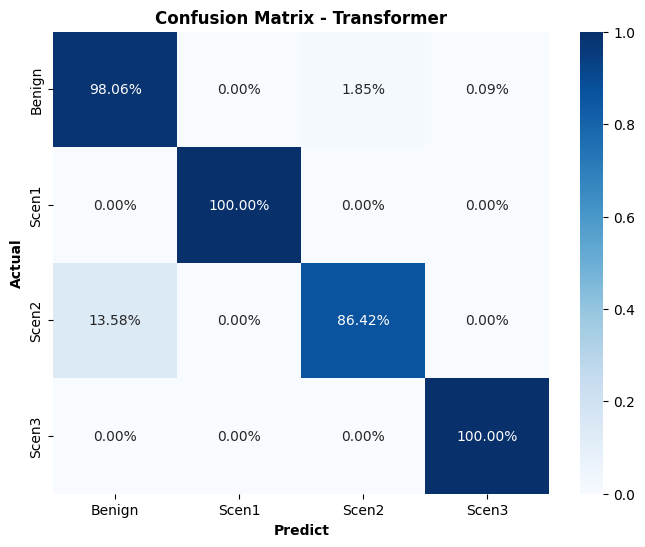

2026-04-07 06:59:03.776641: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



-> [MÀNG LỌC VỚT] Tầng 2 đã soi 88594 mẫu Benign và lôi cổ thêm được:
   + 1386 mẫu Scen2 ẩn mình (Ngưỡng 0.27)!

🏆 BÁO CÁO CUỐI CÙNG (SAU KHI QUA TẦNG 2)
              precision    recall  f1-score   support

      Benign     0.9999    0.9654    0.9824     90321
       Scen1     1.0000    1.0000    1.0000        35
       Scen2     0.0482    0.9506    0.0918       162
       Scen3     0.1000    1.0000    0.1818         9

    accuracy                         0.9654     90527
   macro avg     0.5370    0.9790    0.5640     90527
weighted avg     0.9981    0.9654    0.9807     90527



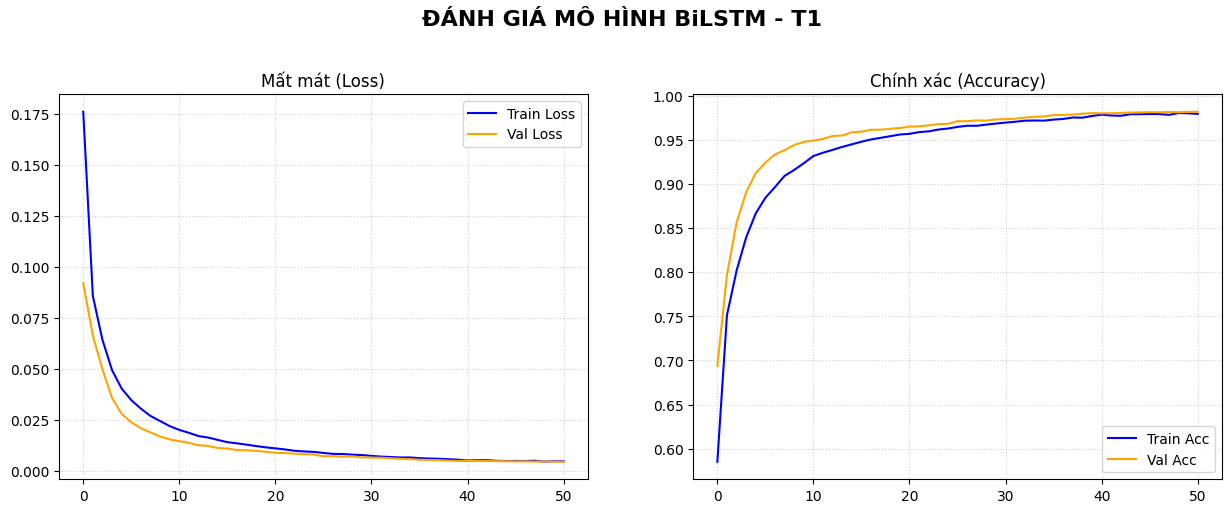

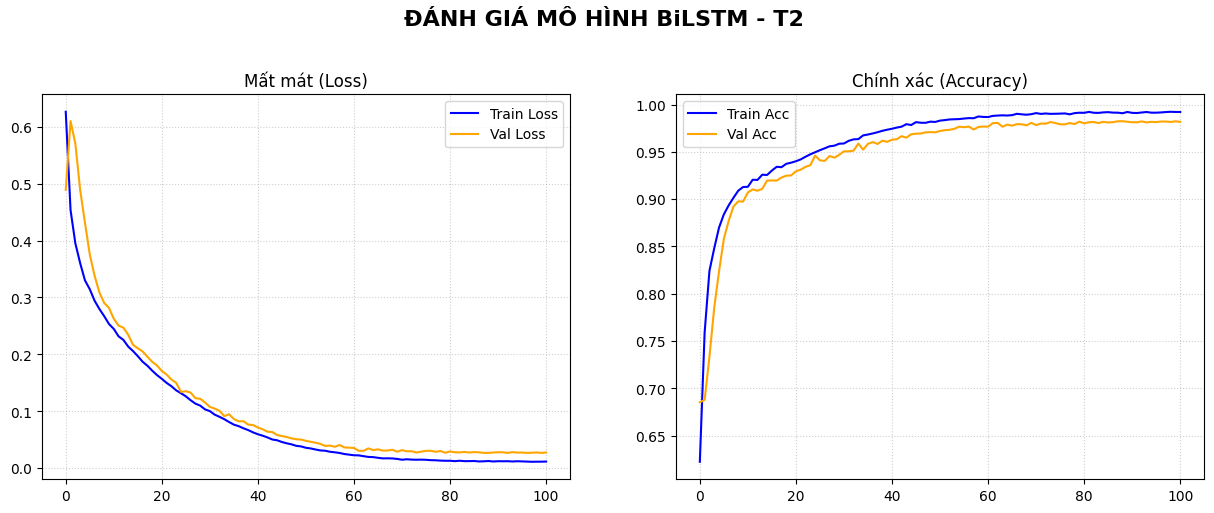

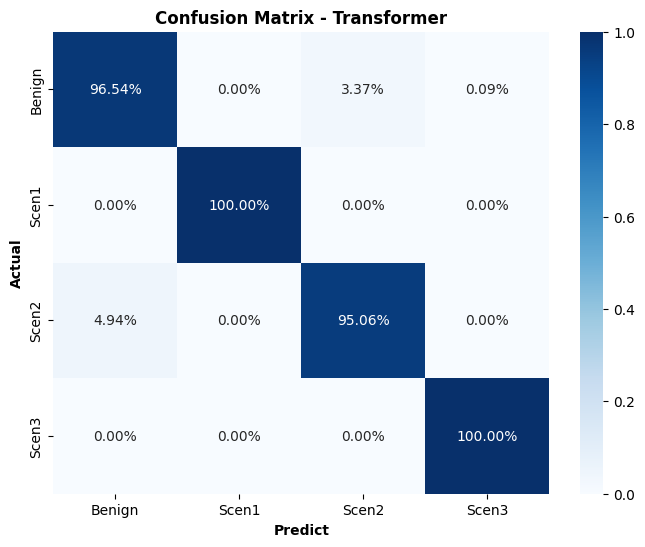

In [1]:
#Transformer Cân Bằng RUS+SMOTE (Tích hợp AUC & Vẽ biểu đồ 3 trục)
import pandas as pd
import numpy as np
import gc
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm
import warnings
import time
import tensorflow as tf
from tensorflow.keras.losses import CategoricalFocalCrossentropy, BinaryFocalCrossentropy
from tensorflow.keras.layers import Input, Dense, Dropout, LayerNormalization, MultiHeadAttention
from tensorflow.keras.layers import GlobalAveragePooling1D, GlobalMaxPooling1D, Concatenate, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os, random

# 🔒 HÀM CỐ ĐỊNH SEED BẮT BUỘC ĐỂ KẾT QUẢ KHÔNG NHẢY MÚA
def set_all_seeds(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
    os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    tf.keras.backend.clear_session()
    print(f"🔒 [HỆ THỐNG] Đã khóa chặt toàn bộ tính ngẫu nhiên với SEED = {seed}")

set_all_seeds(42)
warnings.filterwarnings('ignore')

# ==============================================================================
# 1. LOAD DATA & TIỀN XỬ LÝ (GIỮ NGUYÊN NHƯ CỦA BẠN)
# ==============================================================================
print("\n[1/5] Đang đọc file Parquet và chia tập Train/Val/Test...")
file_path = '/kaggle/input/datasets/phanthanhhoang/cert-r42-session/session_r4.2.parquet'
df = pd.read_parquet(file_path)
df['insider'] = df['insider'].astype(int)

df = df.sort_values(by=['user', 'starttime']).reset_index(drop=True)

exclude_cols = ['insider', 'starttime', 'endtime', 'sessionid', 'user', 'day', 'week']

# drop_cols_leakage = [
#     'http_n_leakf', 'http_leakf_mean_url_len', 'http_leakf_mean_url_depth', 
#     'http_leakf_mean_http_c_len', 'http_leakf_mean_http_c_nwords',
#     'http_n_hackf', 'http_hackf_mean_url_len', 'http_hackf_mean_url_depth', 
#     'http_hackf_mean_http_c_len', 'http_hackf_mean_http_c_nwords',
# ]
# drop_cols_suspect = [
#     'file_n_phof', 'file_phof_mean_file_len', 'file_phof_mean_file_nwords', 
#     'file_phof_n-disk0', 'file_phof_n-disk1', 'file_phof_n-disk2',
#     'http_n_cloudf', 'http_cloudf_mean_url_len', 'http_cloudf_mean_url_depth', 
#     'http_cloudf_mean_http_c_len', 'http_cloudf_mean_http_c_nwords',
# ]
# drop_cols_optional = [
#     'file_compf_n-disk1', 'file_compf_n-disk2', 'file_txtf_n-disk1', 
#     'file_txtf_n-disk2', 'file_exef_n-disk1', 'file_exef_n-disk2',
# ]
feature_cols = [col for col in df.columns if col not in (exclude_cols)]
#feature_cols = [col for col in df.columns if col not in (exclude_cols + drop_cols_leakage+ drop_cols_suspect+drop_cols_optional)]

def split_user_time_multiclass(df, label_col='insider'):
    df = df.sort_values(by='starttime').reset_index(drop=True)
    test_idx = int(len(df) * 0.80)
    df_past = df.iloc[:test_idx].copy()
    df_future = df.iloc[test_idx:].copy()
    
    known_insiders = set(df_past[df_past[label_col] != 0]['user'])
    df_test = df_future[~df_future['user'].isin(known_insiders)].copy()
    
    val_idx = int(len(df_past) * 0.80)
    df_train = df_past.iloc[:val_idx].copy()
    df_val   = df_past.iloc[val_idx:].copy()
    
    return (df_train.sort_values(by=['user', 'starttime']).reset_index(drop=True),
            df_val.sort_values(by=['user', 'starttime']).reset_index(drop=True),
            df_test.sort_values(by=['user', 'starttime']).reset_index(drop=True))
    
df_train, df_val, df_test = split_user_time_multiclass(df, label_col='insider')

# XÓA CỘT ZERO VARIANCE
dead_cols = [c for c in feature_cols if df_train[c].nunique() <= 1]
for d in [df_train, df_val, df_test]:
    d.drop(columns=dead_cols, inplace=True, errors='ignore')
feature_cols = [c for c in feature_cols if c not in dead_cols]

# SCALE DATA
# categorical_cols = ['pc', 'start_with', 'end_with', 'ses_start', 'ses_end', 'role', 'b_unit', 'f_unit', 'dept', 'team', 'ITAdmin']
# cat_cols_to_keep = [c for c in feature_cols if c in categorical_cols]
# num_cols_to_scale = [c for c in feature_cols if c not in cat_cols_to_keep]

# scaler = StandardScaler()
# df_train[num_cols_to_scale] = scaler.fit_transform(df_train[num_cols_to_scale])
# df_val[num_cols_to_scale]   = scaler.transform(df_val[num_cols_to_scale])
# df_test[num_cols_to_scale]  = scaler.transform(df_test[num_cols_to_scale])

# ==============================================================================
# 3️⃣ PHÂN LOẠI (FREQUENCY SMOOTHING) & SCALE CHỌN LỌC
# ==============================================================================
print("\n[3/5] Đang xử lý Categorical (Frequency Smoothing) và Scale Numeric...")

categorical_cols = ['pc', 'start_with', 'end_with', 'role', 'b_unit', 'f_unit', 'dept', 'team', 'ITAdmin']
cat_cols_to_keep = [c for c in feature_cols if c in categorical_cols]
num_cols_to_scale = [c for c in feature_cols if c not in cat_cols_to_keep]

# 1. ÁP DỤNG FREQUENCY ENCODING (CÓ BƠM ĐÁY SMOOTHING)
for col in cat_cols_to_keep:
    # Lập từ điển đếm tỷ lệ % xuất hiện trên tập TRAIN
    freq_map_raw = df_train[col].value_counts(normalize=True).to_dict()
    # 🔴 BÍ KÍP CỦA BẠN: Ép đáy 1% (0.01) để chống rỗ ranh giới cho các giá trị cực hiếm
    freq_map = {k: max(v, 0.01) for k, v in freq_map_raw.items()}
    # Map tỷ lệ lên các tập. Nếu Test có giá trị lạ hoắc, gán = 0.01 (Mức đáy) thay vì 0
    df_train[col] = df_train[col].map(freq_map).fillna(0.01)
    df_val[col]   = df_val[col].map(freq_map).fillna(0.01)
    df_test[col]  = df_test[col].map(freq_map).fillna(0.01)

# 2. SCALE TOÀN BỘ DỮ LIỆU (NHƯNG BỎ CATEGORICAL RA)
# 🔴 BÍ KÍP CỦA BẠN: Giữ nguyên Categorical trong dải [0.01, 1.0], CHỈ Scale Numeric!
scaler = StandardScaler()
df_train[num_cols_to_scale] = scaler.fit_transform(df_train[num_cols_to_scale])
df_val[num_cols_to_scale]   = scaler.transform(df_val[num_cols_to_scale])
df_test[num_cols_to_scale]  = scaler.transform(df_test[num_cols_to_scale])

# Lúc này feature_cols vẫn giữ nguyên trật tự, chỉ là giá trị bên trong đã được tối ưu
print(f" -> Đã ép {len(cat_cols_to_keep)} cột Categorical thành Tần suất (Có Smoothing đáy 1%).")
print(f" -> Đã Scale chuẩn hóa {len(num_cols_to_scale)} cột Numeric.")
print(f" -> Tổng số đặc trưng (Features) đưa vào Tensor 3D: {len(feature_cols)} (Hoàn hảo!)")

# ==============================================================================
# 4️⃣ TẠO TENSOR 3D BẰNG SLIDING WINDOW 
# ==============================================================================
print("\n[2/5] Đang cuộn dữ liệu thành Tensor 3D cho BiLSTM...")

# def create_sliding_windows_3D(df_subset, window_size=5):
#     df_subset = df_subset.sort_values(by=['user', 'starttime']).reset_index(drop=True)
#     X_list, y_list = [], []
#     for user, group in tqdm(df_subset.groupby('user'), leave=False):
#         if len(group) < window_size: continue
#         features, labels = group[feature_cols].values, group['insider'].values
#         for i in range(len(group) - window_size + 1):
#             X_list.append(features[i : i + window_size])
#             y_list.append(np.max(labels[i : i + window_size]))
#     return np.array(X_list), np.array(y_list)

# WINDOW_SIZE = 5
# X_train, y_train = create_sliding_windows_3D(df_train, WINDOW_SIZE)
# X_val, y_val = create_sliding_windows_3D(df_val, WINDOW_SIZE)
# X_test, y_test = create_sliding_windows_3D(df_test, WINDOW_SIZE)
def create_sliding_windows_3D(df_subset, window_size=5, step=1):
    df_subset = df_subset.sort_values(by=['user', 'starttime']).reset_index(drop=True)
    X_list, y_list = [], []
    for user, group in tqdm(df_subset.groupby('user'), leave=False):
        if len(group) < window_size: continue
        features, labels = group[feature_cols].values, group['insider'].values
        
        # 🔴 BÍ KÍP Ở ĐÂY: Thêm 'step' vào vòng lặp range
        for i in range(0, len(group) - window_size + 1, step):
            X_list.append(features[i : i + window_size])
            y_list.append(np.max(labels[i : i + window_size]))
            #y_list.append((labels[i + window_size - 1]))
            
    return np.array(X_list), np.array(y_list)

WINDOW_SIZE = 5
# 🔴 TẬP TRAIN: Ép nhảy 2 bước (hoặc 3) để giảm Overlap, chống học vẹt!
X_train, y_train = create_sliding_windows_3D(df_train, WINDOW_SIZE, step=1) 
# 🔴 TẬP VAL & TEST: Vẫn giữ step=1 để khám nghiệm không bỏ sót bất kỳ giây phút nào!
X_val, y_val = create_sliding_windows_3D(df_val, WINDOW_SIZE, step=1)
X_test, y_test = create_sliding_windows_3D(df_test, WINDOW_SIZE, step=1)

# ==============================================================================
# 🟢 PHẦN 1: MÔ HÌNH CHÍNH (MAIN MODEL BiLSTM - 4 LỚP)
# ==============================================================================
print("\n" + "="*75)
print("🟢 TẦNG 1: HUẤN LUYỆN MAIN MODEL (RANDOM UNDERSAMPLER + SMOTE)")
print("="*75)

N_train, T, F = X_train.shape
X_train_flat = X_train.reshape(N_train, T * F)

rus = RandomUnderSampler(sampling_strategy={0: 30000}, random_state=42)
X_res_flat, y_res = rus.fit_resample(X_train_flat, y_train)

smote_main = SMOTE(sampling_strategy={1: 10000, 2: 10000, 3: 10000}, random_state=42, k_neighbors=2)
X_main_flat, y_main_bal = smote_main.fit_resample(X_res_flat, y_res)

X_train_main = X_main_flat.reshape(-1, T, F)
# ====================================================================
# 🔴 BÍ KÍP CẤP CỨU CỘT CATEGORICAL SAU KHI SMOTE
# ====================================================================
print("-> Đang nắn gân lại các cột Categorical bị SMOTE làm hỏng...")

# Lấy index của các cột không bị scale
cat_indices = [feature_cols.index(col) for col in cat_cols_to_keep]

# Ép kiểu (Làm tròn số thập phân về lại số nguyên chuẩn)
for idx in cat_indices:
    # Round (làm tròn gần nhất) và ép về float/int để tránh lỗi shape
    X_train_main[:, :, idx] = np.round(X_train_main[:, :, idx])

print("✅ Đã làm tròn xong các cột bảo vệ (role, dept, pc...)!")
# 🔴 BÍ KÍP: CHUYỂN NHÃN SANG ONE-HOT ĐỂ TÍNH ĐƯỢC AUC ĐA LỚP
y_main_bal_onehot = tf.keras.utils.to_categorical(y_main_bal, num_classes=4)
y_val_onehot = tf.keras.utils.to_categorical(y_val, num_classes=4)

start_time_t1 = time.time()
# 1. KHỞI TẠO KIẾN TRÚC TRANSFORMER (FUNCTIONAL API)
def build_transformer_t1(T, F):
    inputs = Input(shape=(T, F))
    # Đệm: Ép số features gốc (F) về không gian 64 chiều để Transformer tính toán
    d_model = 64
    x = Dense(d_model)(inputs)
    # Bơm vị trí thời gian (Positional Encoding) để nó biết ai đi trước, ai đi sau
    positions = tf.range(start=0, limit=T, delta=1)
    pos_emb = tf.keras.layers.Embedding(input_dim=T, output_dim=d_model)(positions)
    x = x + pos_emb
    # --- TRANSFORMER BLOCK 1 ---
    attn1 = MultiHeadAttention(num_heads=4, key_dim=d_model)(x, x)
    attn1 = Dropout(0.2)(attn1)
    out1 = LayerNormalization(epsilon=1e-6)(x + attn1) # Cộng Residual 1
    ffn1 = Dense(128, activation='relu')(out1)
    ffn1 = Dropout(0.2)(ffn1)
    ffn1 = Dense(d_model)(ffn1)
    out1 = LayerNormalization(epsilon=1e-6)(out1 + ffn1) # Cộng Residual 2
    # --- TRANSFORMER BLOCK 2 ---
    attn2 = MultiHeadAttention(num_heads=4, key_dim=d_model)(out1, out1)
    attn2 = Dropout(0.2)(attn2)
    out2 = LayerNormalization(epsilon=1e-6)(out1 + attn2) # Cộng Residual 3
    ffn2 = Dense(128, activation='relu')(out2)
    ffn2 = Dropout(0.2)(ffn2)
    ffn2 = Dense(d_model)(ffn2)
    out2 = LayerNormalization(epsilon=1e-6)(out2 + ffn2) # Cộng Residual 4
    # --- ĐẦU RA (GỘP THÔNG TIN) ---
    avg_pool = GlobalAveragePooling1D()(out2) # Lấy trung bình toàn cửa sổ
    max_pool = GlobalMaxPooling1D()(out2)     # Bắt đỉnh tín hiệu đột biến
    concat = Concatenate()([avg_pool, max_pool])
    fc = Dense(32, activation='relu')(concat)
    fc = BatchNormalization()(fc)
    fc = Dropout(0.3)(fc)
    outputs = Dense(4, activation='softmax')(fc) # 🔴 Phân loại 4 lớp
    # Chốt sổ model
    model = Model(inputs=inputs, outputs=outputs)
    return model

# 2. COMPILE & TRAINING (GIỮ NGUYÊN LOGIC CỦA BẠN)
# 🔴 LƯU Ý: Transformer chuộng Learning Rate lớn hơn LSTM một chút để nhanh phá vỡ sức ỳ ban đầu
model_main = build_transformer_t1(T=T, F=F)
focal_loss_t1 = CategoricalFocalCrossentropy(
    gamma=2.0, 
    #alpha=[0.25, 0.75, 0.75] # (Tùy chọn) Có thể bật dòng này nếu muốn ép thêm tạ
)
model_main.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001), 
    loss=focal_loss_t1, 
    metrics=[tf.keras.metrics.AUC(multi_label=True, num_labels=4, name='auc'), 'accuracy']
)
# model_main.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001), 
#     loss='categorical_crossentropy', 
#     metrics=[tf.keras.metrics.AUC(multi_label=True, num_labels=4, name='auc'), 'accuracy']
# )

es_main = EarlyStopping(monitor='val_auc', mode='max', patience=15, restore_best_weights=True)
rlr_main = ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

print("\n🚀 BẮT ĐẦU TRAINING TRANSFORMER TẦNG 1...")
history_main = model_main.fit(
    X_train_main, y_main_bal_onehot, 
    validation_data=(X_val, y_val_onehot),
    epochs=100, 
    batch_size=256, 
    callbacks=[es_main, rlr_main], 
    verbose=1
)
train_time_t1 = time.time() - start_time_t1

# # ==============================================================================
# # 🔵 PHẦN 2: MÔ HÌNH CHUYÊN GIA TOÀN DIỆN (BẮT CẢ SCEN 2 & SCEN 3)
# # ==============================================================================
# print("\n" + "="*75)
# print("🔵 TẦNG 2: HUẤN LUYỆN SALVAGE NET (ĐA LỚP: BENIGN, SCEN 2, SCEN 3)")
# print("="*75)

# # 1. Lọc tập Train & Val (Bao gồm Benign=0, Scen2=2, Scen3=3)
# mask_train = (y_main_bal == 0) | (y_main_bal == 2) | (y_main_bal == 3)
# X_train_expert = X_train_main[mask_train]
# y_train_expert_raw = y_main_bal[mask_train]
# mask_val = (y_val == 0) | (y_val == 2) | (y_val == 3)
# X_val_expert = X_val[mask_val]
# y_val_expert_raw = y_val[mask_val]
# # 2. Map nhãn về 0, 1, 2 để Keras chạy mượt (0: Benign, 1: Scen2, 2: Scen3)
# label_map = {0: 0, 2: 1, 3: 2}
# y_train_expert_mapped = np.vectorize(label_map.get)(y_train_expert_raw)
# y_val_expert_mapped = np.vectorize(label_map.get)(y_val_expert_raw)
# # 3. Chuyển sang One-Hot Encoding (3 lớp)
# y_train_expert = tf.keras.utils.to_categorical(y_train_expert_mapped, num_classes=3)
# y_val_expert = tf.keras.utils.to_categorical(y_val_expert_mapped, num_classes=3)
# # class_weight_expert = {
# #     0: 1.0,     # Benign (Đa số, giữ mức cơ bản)
# #     1: 20.0,    # Scen 2 (Trọng số cao để bắt chặt)
# #     2: 2.0    # Scen 3 (Số lượng quá ít nên phải bơm tạ nặng gấp đôi Scen 2)
# # }
# start_time_t2 = time.time()
# model_expert = Sequential([
#     Bidirectional(LSTM(64, return_sequences=True), input_shape=(T, F)),
#     Dropout(0.2), 
#     Bidirectional(LSTM(32, return_sequences=False)),
#     Dropout(0.1),
#     Dense(32, activation='relu'),
#     BatchNormalization(),
#     Dense(3, activation='softmax') # 🔴 Đã lên 3 lớp
# ])
# # focal_loss_t2 = CategoricalFocalCrossentropy(
# #     gamma=2.0, 
# #     #alpha=[0.25, 0.75, 0.75] # (Tùy chọn) Có thể bật dòng này nếu muốn ép thêm tạ
# # )
# # 🔴 Dùng Categorical và AUC Đa lớp
# # model_expert.compile(
# #     optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001), 
# #     loss=focal_loss_t2,
# #     metrics=[tf.keras.metrics.AUC(multi_label=True, num_labels=3, name='auc'),'accuracy']
# # )
# model_expert.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001), 
#     loss='categorical_crossentropy', 
#     metrics=[tf.keras.metrics.AUC(multi_label=True, num_labels=3, name='auc'), 'accuracy']
# )
# es_expert = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
# rlr_expert = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, min_lr=1e-6, verbose=1)
# history_expert = model_expert.fit(
#     X_train_expert, y_train_expert, 
#     validation_data=(X_val_expert, y_val_expert),
#     #class_weight=class_weight_expert,
#     epochs=100, batch_size=256, callbacks=[es_expert, rlr_expert], verbose=1
# )
# train_time_t2 = time.time() - start_time_t2
# print(f"🚀 TỔNG THỜI GIAN HUẤN LUYỆN: {int((train_time_t1+train_time_t2) // 60)} phút {(train_time_t1+train_time_t2) % 60:.2f} giây")
############################################################################################
# ==============================================================================
# 🔵 PHẦN 2: MÔ HÌNH CHUYÊN GIA (NHỊ PHÂN: BENIGN vs SCEN 2)
# ==============================================================================
print("\n" + "="*75)
print("🔵 TẦNG 2: HUẤN LUYỆN SALVAGE NET (BINARY: BENIGN vs SCEN 2)")
print("="*75)
# 1. Lọc tập Train & Val (Chỉ lấy Benign=0 và Scen2=2)
# mask_train = (y_main_bal == 0) | (y_main_bal == 2)
# X_train_expert = X_train_main[mask_train]
# y_train_expert_raw = y_main_bal[mask_train]
# mask_val = (y_val == 0) | (y_val == 2)
# X_val_expert = X_val[mask_val]
# y_val_expert_raw = y_val[mask_val]
# # 2. Map nhãn về Nhị phân (0: Benign, 1: Scen2)
# # 🔴 LƯU Ý: Đã làm Nhị phân thì KHÔNG CẦN One-Hot Encoding nữa!
# y_train_expert = np.where(y_train_expert_raw == 2, 1, 0)
# y_val_expert = np.where(y_val_expert_raw == 2, 1, 0)
# ==============================================================================
# 🔵 PHẦN 2: MÔ HÌNH CHUYÊN GIA (NHỊ PHÂN: BENIGN vs SCEN 2 - CÂN BẰNG 1:1)
# ==============================================================================
print("\n" + "="*75)
print("🔵 TẦNG 2: HUẤN LUYỆN SALVAGE NET (CÂN BẰNG TUYỆT ĐỐI 1:1)")
print("="*75)
# 1. Lọc tập Train & Val (Chỉ lấy Benign=0 và Scen2=2 từ tập Train cân bằng của T1)
mask_train = (y_main_bal == 0) | (y_main_bal == 2)
X_train_expert_raw = X_train_main[mask_train]
y_train_expert_raw = y_main_bal[mask_train]
mask_val = (y_val == 0) | (y_val == 2)
X_val_expert = X_val[mask_val]
y_val_expert_raw = y_val[mask_val]
# 2. Map nhãn về Nhị phân (0: Benign, 1: Scen2)
y_train_expert_bin = np.where(y_train_expert_raw == 2, 1, 0)
y_val_expert = np.where(y_val_expert_raw == 2, 1, 0)
# ====================================================================
# 🔴 3. BÍ KÍP ÉP TỶ LỆ 1:1 CHO TẬP TRAIN TẦNG 2
# ====================================================================
print("-> Đang xén bớt Benign để ép tỷ lệ 1:1 cho Tầng 2...")
# Lấy ra index của từng nhóm
idx_benign = np.where(y_train_expert_bin == 0)[0]
idx_scen2 = np.where(y_train_expert_bin == 1)[0]
# Đếm số lượng của Scen 2 (Nhóm thiểu số)
num_scen2 = len(idx_scen2)
# Bốc ngẫu nhiên Benign sao cho số lượng vừa bằng đúng Scen 2
np.random.seed(42) # Khóa Seed cho chắc cú
idx_benign_downsampled = np.random.choice(idx_benign, size=num_scen2, replace=False)
# Gom 2 nhóm index lại và xáo trộn lên (Shuffle)
idx_balanced = np.concatenate([idx_benign_downsampled, idx_scen2])
np.random.shuffle(idx_balanced)
# Tạo ra tập Train Tầng 2 MỚI, CHUẨN, VÀ CÂN BẰNG 1:1
X_train_expert = X_train_expert_raw[idx_balanced]
y_train_expert = y_train_expert_bin[idx_balanced]
print(f"✅ Đã cân bằng xong! Phân bổ Train Tầng 2: {dict(zip(*np.unique(y_train_expert, return_counts=True)))}")

start_time_t2 = time.time()
def build_transformer_t2_binary(T, F):
    inputs = Input(shape=(T, F))
    # Ép chiều dữ liệu (d_model = 64)
    d_model = 32
    x = Dense(d_model)(inputs)
    # Positional Encoding (Báo thứ tự thời gian)
    positions = tf.range(start=0, limit=T, delta=1)
    pos_emb = tf.keras.layers.Embedding(input_dim=T, output_dim=d_model)(positions)
    x = x + pos_emb
    # ==========================================
    # 🟢 TRANSFORMER BLOCK 1
    # ==========================================
    attn1 = MultiHeadAttention(num_heads=2, key_dim=d_model)(x, x)
    attn1 = Dropout(0.5)(attn1) # Dropout cao hơn vì data ít (14k)
    out1 = LayerNormalization(epsilon=1e-6)(x + attn1)
    ffn1 = Dense(64, activation='relu')(out1)
    ffn1 = Dropout(0.5)(ffn1)
    ffn1 = Dense(d_model)(ffn1)
    out1 = LayerNormalization(epsilon=1e-6)(out1 + ffn1)
    # ==========================================
    # 🔵 TRANSFORMER BLOCK 2
    # ==========================================
    attn2 = MultiHeadAttention(num_heads=2, key_dim=d_model)(out1, out1)
    attn2 = Dropout(0.5)(attn2)
    out2 = LayerNormalization(epsilon=1e-6)(out1 + attn2)
    ffn2 = Dense(64, activation='relu')(out2)
    ffn2 = Dropout(0.5)(ffn2)
    ffn2 = Dense(d_model)(ffn2)
    out2 = LayerNormalization(epsilon=1e-6)(out2 + ffn2)
    # ==========================================
    # 🔴 ĐẦU RA (NHỊ PHÂN)
    # ==========================================
    avg_pool = GlobalAveragePooling1D()(out2)
    max_pool = GlobalMaxPooling1D()(out2)
    concat = Concatenate()([avg_pool, max_pool])
    # Lớp Dense có L2 Regularization để ép trọng số không phình to
    fc = Dense(16, activation='relu', kernel_regularizer=l2(0.01))(concat)
    fc = BatchNormalization()(fc)
    fc = Dropout(0.5)(fc)
    # 🔴 ĐẦU RA 1 NƠ-RON, HÀM SIGMOID CHO NHỊ PHÂN
    outputs = Dense(1, activation='sigmoid')(fc)
    model = Model(inputs=inputs, outputs=outputs)
    return model

# Khởi tạo mô hình
model_expert = build_transformer_t2_binary(T=T, F=F)
focal_loss_t2 = BinaryFocalCrossentropy(
    gamma=2.0, 
    #alpha=[0.25, 0.75, 0.75] # (Tùy chọn) Có thể bật dòng này nếu muốn ép thêm tạ
)
model_expert.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), 
    loss=focal_loss_t2, 
    metrics=[tf.keras.metrics.AUC(name='auc'), 'accuracy']
)
# model_expert.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), 
#     loss='binary_crossentropy', 
#     metrics=[tf.keras.metrics.AUC(name='auc'), 'accuracy']
# )
# 🔴 BỘ CALLBACKS CHUẨN (Patience ES > RLR)
# es_expert = EarlyStopping(monitor='val_auc', mode='max', patience=15, restore_best_weights=True)
# rlr_expert = ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5, patience=4, min_lr=1e-6, verbose=1)
es_expert = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
rlr_expert = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
print("\n🚀 BẮT ĐẦU TRAINING TẦNG 2 (SALVAGE NET)...")
history_expert = model_expert.fit(
    X_train_expert, y_train_expert, 
    validation_data=(X_val_expert, y_val_expert),
    epochs=200, 
    batch_size=256, # Batch nhỏ vì data ít
    callbacks=[es_expert, rlr_expert], 
    verbose=1
)
train_time_t2 = time.time() - start_time_t2
print(f"🚀 TỔNG THỜI GIAN HUẤN LUYỆN: {int((train_time_t1+train_time_t2) // 60)} phút {(train_time_t1+train_time_t2) % 60:.2f} giây")
############################################################################################
# ==============================================================================
# 🔴 PHẦN 3: ĐÁNH GIÁ LIÊN HOÀN (SALVAGE NET S1, S2 & S3)
# ==============================================================================
print("\n[4/4] Khám nghiệm tập Test qua Màng Lọc Vớt Toàn Diện...")
classes_names = ['Benign', 'Scen1', 'Scen2', 'Scen3']
probs_main = model_main.predict(X_test, verbose=0)
preds_main = np.argmax(probs_main, axis=1)
print("\n" + "="*50)
print("📊 BÁO CÁO ĐỘC LẬP: TẦNG 1 (MAIN MODEL)")
print("="*50)
print(classification_report(y_test, preds_main, target_names=classes_names, digits=4, zero_division=0))

cm_final_t1 = confusion_matrix(y_test, preds_main)
cmn_final_t1 = cm_final_t1.astype('float') / cm_final_t1.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(8, 6))
sns.heatmap(cmn_final_t1, annot=True, fmt='.2%', cmap='Blues', xticklabels=classes_names, yticklabels=classes_names)
plt.xlabel('Predict', fontweight='bold')
plt.ylabel('Actual', fontweight='bold')
plt.title('Confusion Matrix - Transformer', fontweight='bold')
plt.show()

# --- MÀNG LỌC VỚT TẦNG 2 CHO SCEN 2 & SCEN 3 ---
final_preds = preds_main.copy()
review_idx = np.where(preds_main == 0)[0] # Trích xuất nhóm bị phán Benign
############################################################################################
# if len(review_idx) > 0:
#     # probs_expert có shape (N, 3): Cột 0(Benign), Cột 1(Scen2), Cột 2(Scen3)
#     probs_expert = model_expert.predict(X_test[review_idx], verbose=0)
#     # 🔴 ĐẶT NGƯỠNG VỚT ĐỘC LẬP CHO TỪNG KỊCH BẢN
#     THRESHOLD_SCEN2 = 0.1  # Scen 2 đông hơn, để ngưỡng cao một chút cho đỡ vớt nhầm rác
#     THRESHOLD_SCEN3 = 0.4  # Scen 3 quá hiếm, hạ lưới sát đáy biển để vét
#     new_preds = np.zeros(len(review_idx), dtype=int)
#     for i in range(len(probs_expert)):
#         prob_scen2 = probs_expert[i, 1]
#         prob_scen3 = probs_expert[i, 2]
#         # Kiểm tra xem thằng nào qua vòng gửi xe
#         pass_s2 = prob_scen2 >= THRESHOLD_SCEN2
#         pass_s3 = prob_scen3 >= THRESHOLD_SCEN3
#         # KỊCH BẢN A: Cả 2 đều vượt ngưỡng -> So găng xem xác suất thằng nào lớn hơn
#         if pass_s2 and pass_s3:
#             if prob_scen2 > prob_scen3:
#                 new_preds[i] = 2 
#             else:
#                 new_preds[i] = 3
#         # KỊCH BẢN B: Chỉ có Scen 2 vượt ngưỡng
#         elif pass_s2:
#             new_preds[i] = 2
#         # KỊCH BẢN C: Chỉ có Scen 3 vượt ngưỡng
#         elif pass_s3:
#             new_preds[i] = 3
#     # Cập nhật đè lên mảng final
#     mask_update = new_preds > 0
#     indices_to_update = review_idx[mask_update]
#     final_preds[indices_to_update] = new_preds[mask_update]
#     print(f"\n-> [MÀNG LỌC VỚT] Tầng 2 đã soi {len(review_idx)} mẫu Benign và lôi cổ thêm được:")
#     print(f"   + {np.sum(new_preds == 2)} mẫu Scen2 ẩn mình (Ngưỡng {THRESHOLD_SCEN2})!")
#     print(f"   + {np.sum(new_preds == 3)} mẫu Scen3 ẩn mình (Ngưỡng {THRESHOLD_SCEN3})!")
############################################################################################
############################################################################################
if len(review_idx) > 0:
    # probs_expert lúc này là mảng 2D shape (N, 1) chứa tỷ lệ % là Scen 2
    probs_expert = model_expert.predict(X_test[review_idx], verbose=0)
    # Ép phẳng về mảng 1D (N,) cho dễ tính toán
    probs_scen2 = probs_expert.flatten()
    # 🔴 ĐẶT NGƯỠNG VỚT CHO SCEN 2 (Tùy chỉnh 0.15 - 0.3)
    THRESHOLD_SCEN2 = 0.27  
    # Tìm những đứa vượt ngưỡng
    is_scen2 = probs_scen2 >= THRESHOLD_SCEN2
    # Cập nhật mảng kết quả
    new_preds = np.zeros(len(review_idx), dtype=int)
    new_preds[is_scen2] = 2 
    # Đè lên mảng final_preds gốc
    mask_update = new_preds == 2
    indices_to_update = review_idx[mask_update]
    final_preds[indices_to_update] = 2
    print(f"\n-> [MÀNG LỌC VỚT] Tầng 2 đã soi {len(review_idx)} mẫu Benign và lôi cổ thêm được:")
    print(f"   + {np.sum(new_preds == 2)} mẫu Scen2 ẩn mình (Ngưỡng {THRESHOLD_SCEN2})!")
############################################################################################
# Phía dưới này bạn cứ giữ nguyên phần code vẽ Biểu đồ và In CM của tui lúc trước nhé!
# ==============================================================================
# XUẤT BÁO CÁO CUỐI CÙNG & BIỂU ĐỒ (NÂNG CẤP VỚI AUC)
# ==============================================================================
print("\n" + "="*50)
print("🏆 BÁO CÁO CUỐI CÙNG (SAU KHI QUA TẦNG 2)")
print("="*50)
print(classification_report(y_test, final_preds, target_names=classes_names, digits=4, zero_division=0))

# 🔴 VẼ 3 TRỤC: LOSS, ACCURACY VÀ AUC CHO TẦNG 1
fig1, axes1 = plt.subplots(1, 2, figsize=(15, 5))
fig1.suptitle('ĐÁNH GIÁ MÔ HÌNH BiLSTM - T1', fontsize=16, fontweight='bold', y=1.05)

axes1[0].plot(history_main.history['loss'], label='Train Loss', color='blue')
axes1[0].plot(history_main.history['val_loss'], label='Val Loss', color='orange')
axes1[0].set_title('Mất mát (Loss)')
axes1[0].legend(); axes1[0].grid(True, linestyle=':', alpha=0.6)

axes1[1].plot(history_main.history['accuracy'], label='Train Acc', color='blue')
axes1[1].plot(history_main.history['val_accuracy'], label='Val Acc', color='orange')
axes1[1].set_title('Chính xác (Accuracy)')
axes1[1].legend(); axes1[1].grid(True, linestyle=':', alpha=0.6)

# axes1[2].plot(history_main.history['auc'], label='Train AUC', color='blue')
# axes1[2].plot(history_main.history['val_auc'], label='Val AUC', color='orange')
# axes1[2].set_title('Diện tích dưới đường cong (AUC)')
# axes1[2].legend(); axes1[2].grid(True, linestyle='--', alpha=0.6)
plt.show()

# 🔴 VẼ 3 TRỤC: LOSS, ACCURACY VÀ AUC CHO TẦNG 2
fig2, axes2 = plt.subplots(1, 2, figsize=(15, 5))
fig2.suptitle('ĐÁNH GIÁ MÔ HÌNH BiLSTM - T2', fontsize=16, fontweight='bold', y=1.05)

axes2[0].plot(history_expert.history['loss'], label='Train Loss', color='blue')
axes2[0].plot(history_expert.history['val_loss'], label='Val Loss', color='orange')
axes2[0].set_title('Mất mát (Loss)')
axes2[0].legend(); axes2[0].grid(True, linestyle=':', alpha=0.6)

axes2[1].plot(history_expert.history['accuracy'], label='Train Acc', color='blue')
axes2[1].plot(history_expert.history['val_accuracy'], label='Val Acc', color='orange')
axes2[1].set_title('Chính xác (Accuracy)')
axes2[1].legend(); axes2[1].grid(True, linestyle=':', alpha=0.6)

# axes2[2].plot(history_expert.history['auc'], label='Train AUC', color='green')
# axes2[2].plot(history_expert.history['val_auc'], label='Val AUC', color='red')
# axes2[2].set_title('Diện tích dưới đường cong (AUC)')
# axes2[2].legend(); axes2[2].grid(True, linestyle='--', alpha=0.6)
plt.show()

# MA TRẬN NHẦM LẪN
cm_final = confusion_matrix(y_test, final_preds)
cmn_final = cm_final.astype('float') / cm_final.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8, 6))
sns.heatmap(cmn_final, annot=True, fmt='.2%', cmap='Blues', xticklabels=classes_names, yticklabels=classes_names)
plt.xlabel('Predict', fontweight='bold')
plt.ylabel('Actual', fontweight='bold')
plt.title('Confusion Matrix - Transformer', fontweight='bold')
plt.show()

In [ ]:
cm_final_t1 = confusion_matrix(y_test, preds_main)
cmn_final_t1 = cm_final_t1.astype('float') / cm_final_t1.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(8, 6))
sns.heatmap(cmn_final_t1, annot=True, fmt='.2%', cmap='Blues', xticklabels=classes_names, yticklabels=classes_names)
plt.xlabel('Predict', fontweight='bold')
plt.ylabel('Actual', fontweight='bold')
plt.title('Confusion Matrix - Transformer', fontweight='bold')
plt.show()

# --- MÀNG LỌC VỚT TẦNG 2 CHO SCEN 2 & SCEN 3 ---
final_preds = preds_main.copy()
review_idx = np.where(preds_main == 0)[0] # Trích xuất nhóm bị phán Benign
############################################################################################
# if len(review_idx) > 0:
#     # probs_expert có shape (N, 3): Cột 0(Benign), Cột 1(Scen2), Cột 2(Scen3)
#     probs_expert = model_expert.predict(X_test[review_idx], verbose=0)
#     # 🔴 ĐẶT NGƯỠNG VỚT ĐỘC LẬP CHO TỪNG KỊCH BẢN
#     THRESHOLD_SCEN2 = 0.1  # Scen 2 đông hơn, để ngưỡng cao một chút cho đỡ vớt nhầm rác
#     THRESHOLD_SCEN3 = 0.4  # Scen 3 quá hiếm, hạ lưới sát đáy biển để vét
#     new_preds = np.zeros(len(review_idx), dtype=int)
#     for i in range(len(probs_expert)):
#         prob_scen2 = probs_expert[i, 1]
#         prob_scen3 = probs_expert[i, 2]
#         # Kiểm tra xem thằng nào qua vòng gửi xe
#         pass_s2 = prob_scen2 >= THRESHOLD_SCEN2
#         pass_s3 = prob_scen3 >= THRESHOLD_SCEN3
#         # KỊCH BẢN A: Cả 2 đều vượt ngưỡng -> So găng xem xác suất thằng nào lớn hơn
#         if pass_s2 and pass_s3:
#             if prob_scen2 > prob_scen3:
#                 new_preds[i] = 2 
#             else:
#                 new_preds[i] = 3
#         # KỊCH BẢN B: Chỉ có Scen 2 vượt ngưỡng
#         elif pass_s2:
#             new_preds[i] = 2
#         # KỊCH BẢN C: Chỉ có Scen 3 vượt ngưỡng
#         elif pass_s3:
#             new_preds[i] = 3
#     # Cập nhật đè lên mảng final
#     mask_update = new_preds > 0
#     indices_to_update = review_idx[mask_update]
#     final_preds[indices_to_update] = new_preds[mask_update]
#     print(f"\n-> [MÀNG LỌC VỚT] Tầng 2 đã soi {len(review_idx)} mẫu Benign và lôi cổ thêm được:")
#     print(f"   + {np.sum(new_preds == 2)} mẫu Scen2 ẩn mình (Ngưỡng {THRESHOLD_SCEN2})!")
#     print(f"   + {np.sum(new_preds == 3)} mẫu Scen3 ẩn mình (Ngưỡng {THRESHOLD_SCEN3})!")
############################################################################################
############################################################################################
if len(review_idx) > 0:
    # probs_expert lúc này là mảng 2D shape (N, 1) chứa tỷ lệ % là Scen 2
    probs_expert = model_expert.predict(X_test[review_idx], verbose=0)
    # Ép phẳng về mảng 1D (N,) cho dễ tính toán
    probs_scen2 = probs_expert.flatten()
    # 🔴 ĐẶT NGƯỠNG VỚT CHO SCEN 2 (Tùy chỉnh 0.15 - 0.3)
    THRESHOLD_SCEN2 = 0.25  
    # Tìm những đứa vượt ngưỡng
    is_scen2 = probs_scen2 >= THRESHOLD_SCEN2
    # Cập nhật mảng kết quả
    new_preds = np.zeros(len(review_idx), dtype=int)
    new_preds[is_scen2] = 2 
    # Đè lên mảng final_preds gốc
    mask_update = new_preds == 2
    indices_to_update = review_idx[mask_update]
    final_preds[indices_to_update] = 2
    print(f"\n-> [MÀNG LỌC VỚT] Tầng 2 đã soi {len(review_idx)} mẫu Benign và lôi cổ thêm được:")
    print(f"   + {np.sum(new_preds == 2)} mẫu Scen2 ẩn mình (Ngưỡng {THRESHOLD_SCEN2})!")
############################################################################################
# Phía dưới này bạn cứ giữ nguyên phần code vẽ Biểu đồ và In CM của tui lúc trước nhé!
# ==============================================================================
# XUẤT BÁO CÁO CUỐI CÙNG & BIỂU ĐỒ (NÂNG CẤP VỚI AUC)
# ==============================================================================
print("\n" + "="*50)
print("🏆 BÁO CÁO CUỐI CÙNG (SAU KHI QUA TẦNG 2)")
print("="*50)
print(classification_report(y_test, final_preds, target_names=classes_names, digits=4, zero_division=0))

# 🔴 VẼ 3 TRỤC: LOSS, ACCURACY VÀ AUC CHO TẦNG 1
fig1, axes1 = plt.subplots(1, 2, figsize=(15, 5))
fig1.suptitle('ĐÁNH GIÁ MÔ HÌNH BiLSTM - T1', fontsize=16, fontweight='bold', y=1.05)

axes1[0].plot(history_main.history['loss'], label='Train Loss', color='blue')
axes1[0].plot(history_main.history['val_loss'], label='Val Loss', color='orange')
axes1[0].set_title('Mất mát (Loss)')
axes1[0].legend(); axes1[0].grid(True, linestyle=':', alpha=0.6)

axes1[1].plot(history_main.history['accuracy'], label='Train Acc', color='blue')
axes1[1].plot(history_main.history['val_accuracy'], label='Val Acc', color='orange')
axes1[1].set_title('Chính xác (Accuracy)')
axes1[1].legend(); axes1[1].grid(True, linestyle=':', alpha=0.6)

# axes1[2].plot(history_main.history['auc'], label='Train AUC', color='blue')
# axes1[2].plot(history_main.history['val_auc'], label='Val AUC', color='orange')
# axes1[2].set_title('Diện tích dưới đường cong (AUC)')
# axes1[2].legend(); axes1[2].grid(True, linestyle='--', alpha=0.6)
plt.show()

# 🔴 VẼ 3 TRỤC: LOSS, ACCURACY VÀ AUC CHO TẦNG 2
fig2, axes2 = plt.subplots(1, 2, figsize=(15, 5))
fig2.suptitle('ĐÁNH GIÁ MÔ HÌNH BiLSTM - T2', fontsize=16, fontweight='bold', y=1.05)

axes2[0].plot(history_expert.history['loss'], label='Train Loss', color='blue')
axes2[0].plot(history_expert.history['val_loss'], label='Val Loss', color='orange')
axes2[0].set_title('Mất mát (Loss)')
axes2[0].legend(); axes2[0].grid(True, linestyle=':', alpha=0.6)

axes2[1].plot(history_expert.history['accuracy'], label='Train Acc', color='blue')
axes2[1].plot(history_expert.history['val_accuracy'], label='Val Acc', color='orange')
axes2[1].set_title('Chính xác (Accuracy)')
axes2[1].legend(); axes2[1].grid(True, linestyle=':', alpha=0.6)

# axes2[2].plot(history_expert.history['auc'], label='Train AUC', color='green')
# axes2[2].plot(history_expert.history['val_auc'], label='Val AUC', color='red')
# axes2[2].set_title('Diện tích dưới đường cong (AUC)')
# axes2[2].legend(); axes2[2].grid(True, linestyle='--', alpha=0.6)
plt.show()

# MA TRẬN NHẦM LẪN
cm_final = confusion_matrix(y_test, final_preds)
cmn_final = cm_final.astype('float') / cm_final.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8, 6))
sns.heatmap(cmn_final, annot=True, fmt='.2%', cmap='Blues', xticklabels=classes_names, yticklabels=classes_names)
plt.xlabel('Predict', fontweight='bold')
plt.ylabel('Actual', fontweight='bold')
plt.title('Confusion Matrix - Transformer', fontweight='bold')
plt.show()